# Set Up
If running this notebook in a fresh environment, please install the required packages by running the cell below once.

In [175]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


# Reading in the Data

In [176]:
import pandas as pd

df = pd.read_csv("datasets/data.csv")

# Q0. Explore the dataset

## Exploratory Data Analysis (EDA)

In [177]:
print("shape:", df.shape) # rows, columns

df.head() # beginning of the dataframe

shape: (777549, 30)


,date,racecourse_country,racecourse_name,race_time,race_id,race_distance,race_type,race_type_simple,going_clean,n_runners,...,ltp_5min,obs__bsp,obs__racing_post_rating,obs__Place,obs__uposition,obs__is_winner,obs__top_speed,obs__distance_to_winner,obs__pos_prize,obs__completion_time
0,2015-05-01,GB,Chepstow,13:40,49699,2435.0472,Flat,Flat Turf,Good,8,...,7.8,9.12,82.0,3,3,0,48.0,2.5,721.50,155.95
1,2015-05-01,GB,Chepstow,13:40,49699,2435.0472,Flat,Flat Turf,Good,8,...,5.8,7.00,81.0,2,2,0,47.0,0.5,1443.75,155.61
2,2015-05-01,GB,Chepstow,13:40,49699,2435.0472,Flat,Flat Turf,Good,8,...,12.0,9.28,45.0,8,8,0,11.0,23.0,0.00,159.36
3,2015-05-01,GB,Chepstow,13:40,49699,2435.0472,Flat,Flat Turf,Good,8,...,34.0,18.00,62.0,6,6,0,28.0,13.0,0.00,157.70
4,2015-05-01,GB,Chepstow,13:40,49699,2435.0472,Flat,Flat Turf,Good,8,...,7.6,7.40,77.0,5,5,0,44.0,6.0,0.00,156.53


df.head() provides a quick snapshot of the first few rows to:
- confirm columns loaded correctly and values look sensible
- spot parsing issues (for example numbers read as strings, stray whitespace)
- verify sort order before time-based splits
- sanity-check early preprocessing effects

In [178]:
df.tail() # end of the dataframe

,date,racecourse_country,racecourse_name,race_time,race_id,race_distance,race_type,race_type_simple,going_clean,n_runners,...,ltp_5min,obs__bsp,obs__racing_post_rating,obs__Place,obs__uposition,obs__is_winner,obs__top_speed,obs__distance_to_winner,obs__pos_prize,obs__completion_time
777544,2022-04-30,GB,Hexham,20:20,122808,4037.076,Chase,Chase,Good,11,...,20.0,16.57,72.0,3,3,0,55.0,20.5,890.34,323.18
777545,2022-04-30,GB,Hexham,20:20,122808,4037.076,Chase,Chase,Good,11,...,10.0,7.43,49.0,10,10,0,26.0,40.0,0.00,330.24
777546,2022-04-30,GB,Hexham,20:20,122808,4037.076,Chase,Chase,Good,11,...,5.1,5.30,99.0,2,2,0,83.0,9.5,1781.39,320.98
777547,2022-04-30,GB,Hexham,20:20,122808,4037.076,Chase,Chase,Good,11,...,6.4,7.02,87.0,4,4,0,68.0,23.0,445.88,323.68
777548,2022-04-30,GB,Hexham,20:20,122808,4037.076,Chase,Chase,Good,11,...,11.5,14.25,88.0,8,8,0,70.0,27.3,0.00,324.54


df.tail() shows the last few rows to:
- confirm if the dataset is correctly sorted to the end
- catch trailing missing values or anomalies not visible at the top

#### inspecting df structure

In [179]:
df.info() # idx range, column names, non-null counts, dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777549 entries, 0 to 777548
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     777549 non-null  object 
 1   racecourse_country       777549 non-null  object 
 2   racecourse_name          777549 non-null  object 
 3   race_time                777549 non-null  object 
 4   race_id                  777549 non-null  int64  
 5   race_distance            777549 non-null  float64
 6   race_type                777549 non-null  object 
 7   race_type_simple         777549 non-null  object 
 8   going_clean              777549 non-null  object 
 9   n_runners                777549 non-null  int64  
 10  horse_id                 777549 non-null  int64  
 11  horse_name               777549 non-null  object 
 12  age                      777549 non-null  int64  
 13  official_rating          573933 non-null  float64
 14  carr

df.info() gives a compact overview of the dataset: column names, non‑null counts, data types, and memory usage. This helps with:
- spoting missing data quickly to plan imputation or filtering
- catch columns with unexpected types (for example numbers stored as strings)
- gauge memory usage to avoid performance surprises (178.0+ MB)
- verify basic structure (index range, column presence) before preprocessing

a key thing to notice early on is the dtype of the date and race_time cols

#### missing data, duplicates and basic uniqueness checks

In [180]:
# Missing values per column
print("Missing values per column:\n", df.isna().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Number of unique values per column
print("\nNumber of unique values per column:\n", df.nunique())

# value counts for specific columns with only two unique values
print("\nValue counts for racecourse_country:\n", df["racecourse_country"].value_counts())
print("\nValue counts for obs__is_winner:\n", df["obs__is_winner"].value_counts())

Missing values per column:
 date                            0
racecourse_country              0
racecourse_name                 0
race_time                       0
race_id                         0
race_distance                   0
race_type                       0
race_type_simple                0
going_clean                     0
n_runners                       0
horse_id                        0
horse_name                      0
age                             0
official_rating            203616
carried_weight                  0
draw                            0
jockey_id                       0
jockey_name                     0
trainer_id                      0
trainer_name                    0
ltp_5min                     1536
obs__bsp                        0
obs__racing_post_rating     64612
obs__Place                      0
obs__uposition                  0
obs__is_winner                  0
obs__top_speed             163569
obs__distance_to_winner         0
obs__pos_prize      

Several columns havie missing values, including `official rating`, `ltp_5min`, and evaluation only columns `obs__*`

I will focus on handling `official_rating` and `ltp_5min` in next stages of the notebook, the `obs__*` variables are only used for evaluation later, not as model inputs

There are no duplicate rows.

There are no constant columns.

also as expected obs__is_winner is highly imbalanced and this will be important later in modeling

#### histograms for all numeric columns

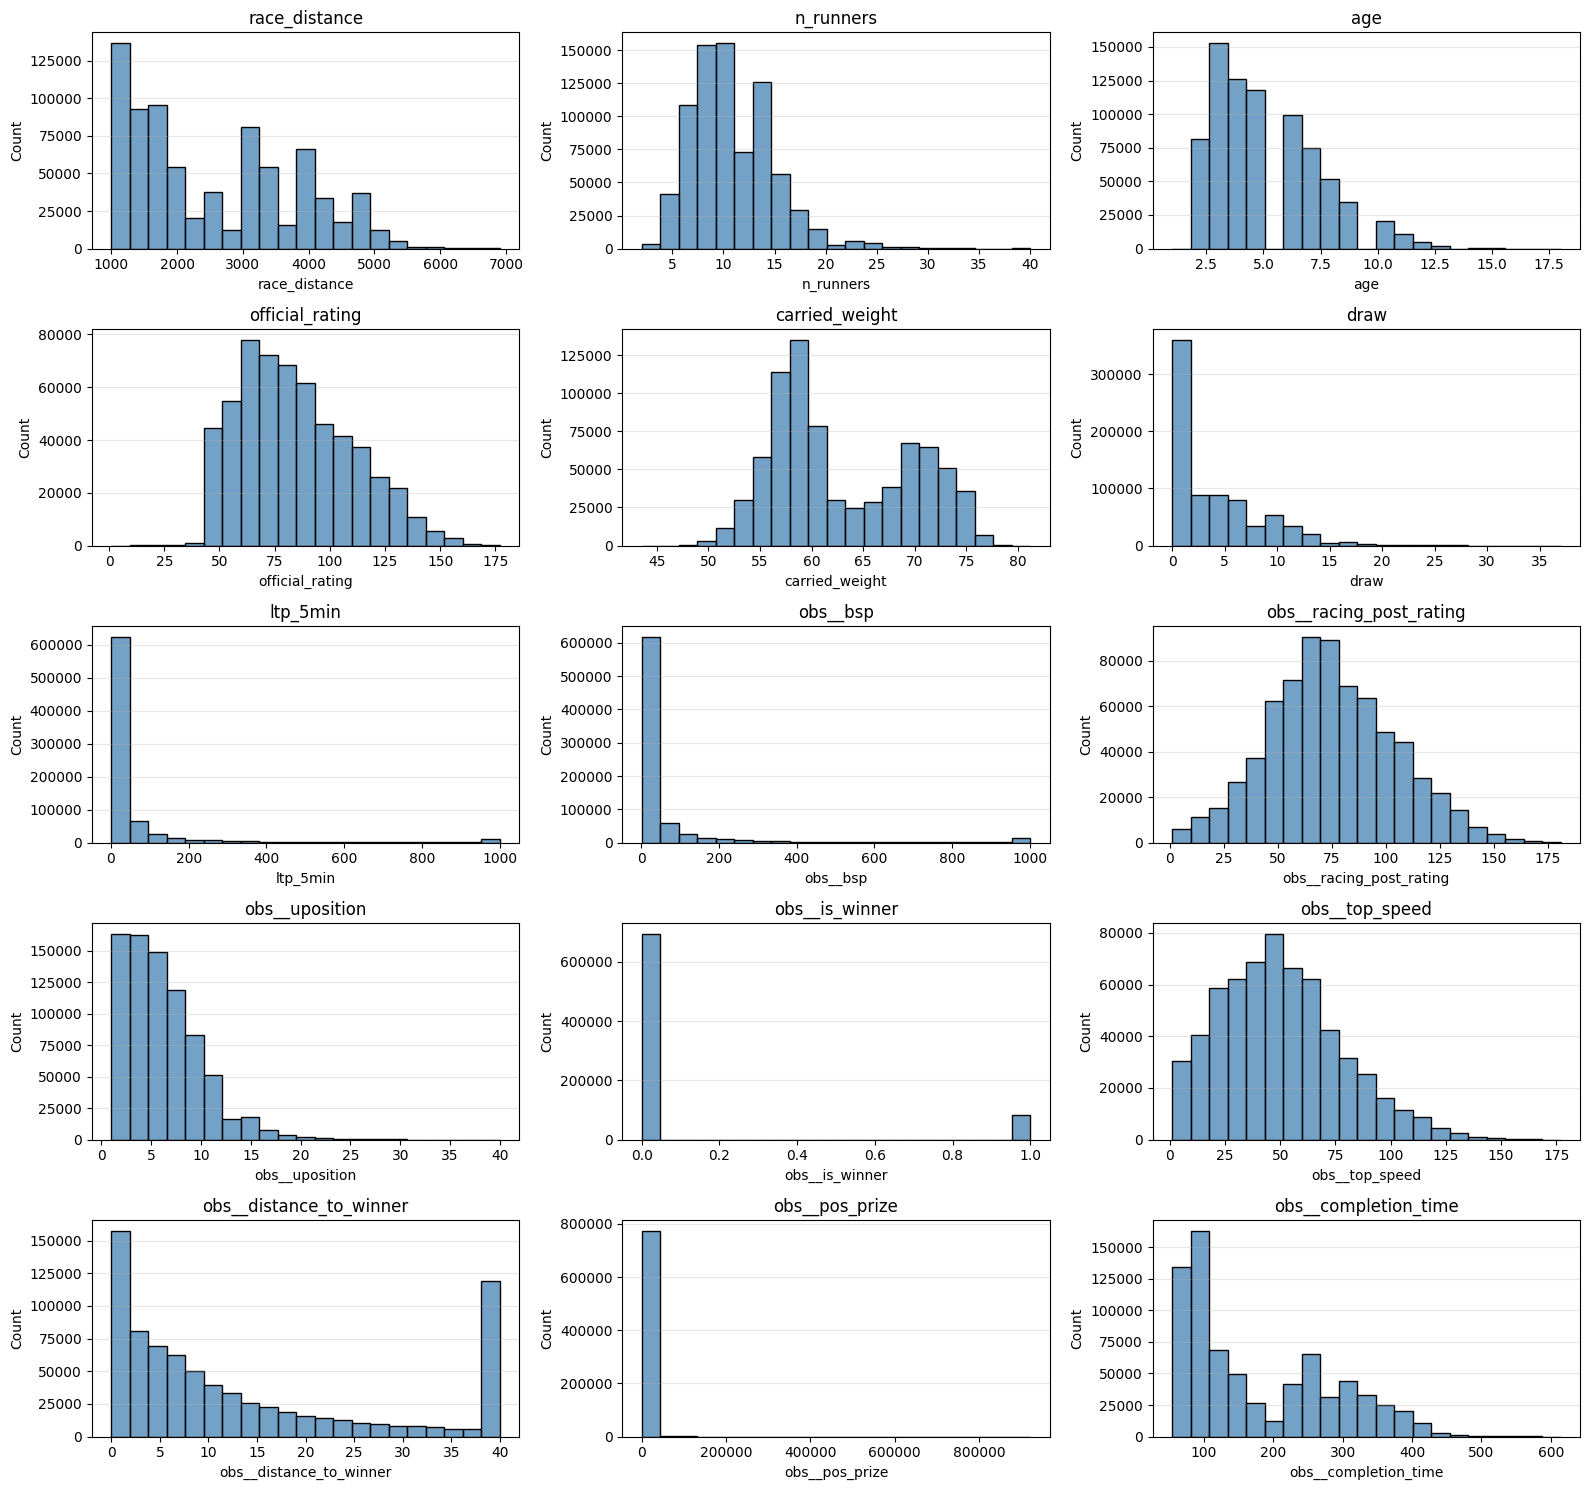

In [181]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# histograms for all numeric columns (excluding obvious id columns)
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

# exclude columns that look like ids (end with "_id")
numeric_cols = [c for c in numeric_cols_all if not c.endswith("_id")]

if len(numeric_cols) == 0:
    print("no numeric columns found to plot.")
else:
    # calculate grid dimensions: 3 columns per row
    n = len(numeric_cols)
    cols_per_row = 3
    nrows = math.ceil(n / cols_per_row)

    # create subplot grid with appropriate figure size
    fig, axes = plt.subplots(nrows=nrows, ncols=cols_per_row, figsize=(16, max(3, nrows) * 3))
    
    # flatten axes array to handle both single row and multi-row cases
    axes = np.array(axes).reshape(-1)

    # plot histogram for each numeric column
    for i, col in enumerate(numeric_cols):
        # drop missing values before plotting
        sns.histplot(df[col].dropna(), bins="sturges", kde=False, ax=axes[i], color="steelblue")
        axes[i].set_title(col)
        # add light grid for readability
        axes[i].grid(True, axis="y", alpha=0.3)

    # hide any unused subplot axes (when total columns < grid cells)
    for j in range(len(numeric_cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## key observations from numeric distributions

the histograms reveal several important patterns in the numeric features:

**race distance:**
- wide range from sprint distances (about 1000) to long-distance races (more than 4000)
- multiple peaks suggest distinct race categories (sprints, middle distance, longer races)

**number of runners (n_runners):**
- most races have between 7-15 runners
- small tail extends to 40+ runners in some races

**age distribution:**
- most horses compete between ages 3-7, with a peak around 4-5 years
- very few horses race beyond age 10, consistent with typical racing careers

**official rating:**
- roughly bell-shaped, centered around 70-80
- range from 40 to 175+ reflects different class levels
- missing values already noted, to be handled later in the notebook

**carried weight:**
- relatively tight distribution centered around 60
- reflects typical jockey + equipment weights

**draw position:**
- lots of runs have low starting stall numbers.
- n_runners distribution extends past largest observed draw value indicating there might be lots of races that dont use stalls

**ltp_5min (betting odds):**
- heavily right-skewed with extreme outliers to 1000
- most horses have low odds, indicating market concentration on favorites
- long tail represents longshots, justifying log transformation for modeling
- small amount of missing values

**observation variables (obs__*):**
- `obs__racing_post_rating`: symmetric, similar to official_rating
- `obs__top_speed`: relatively normal distribution
- `obs__distance_to_winner`: right-skewed and tight spread relative to the length of some races (most horses finish close to winner, some far behind)
- `obs__completion_time`: wider spread, right-skewed

these distributions inform preprocessing decisions: log transformation for `ltp_5min`, careful handling of draw for different race types, or potentially reasonable to drop all together, then `official_rating` and post-race metrics capture similar underlying ability.

#### bar charts for all categorical columns

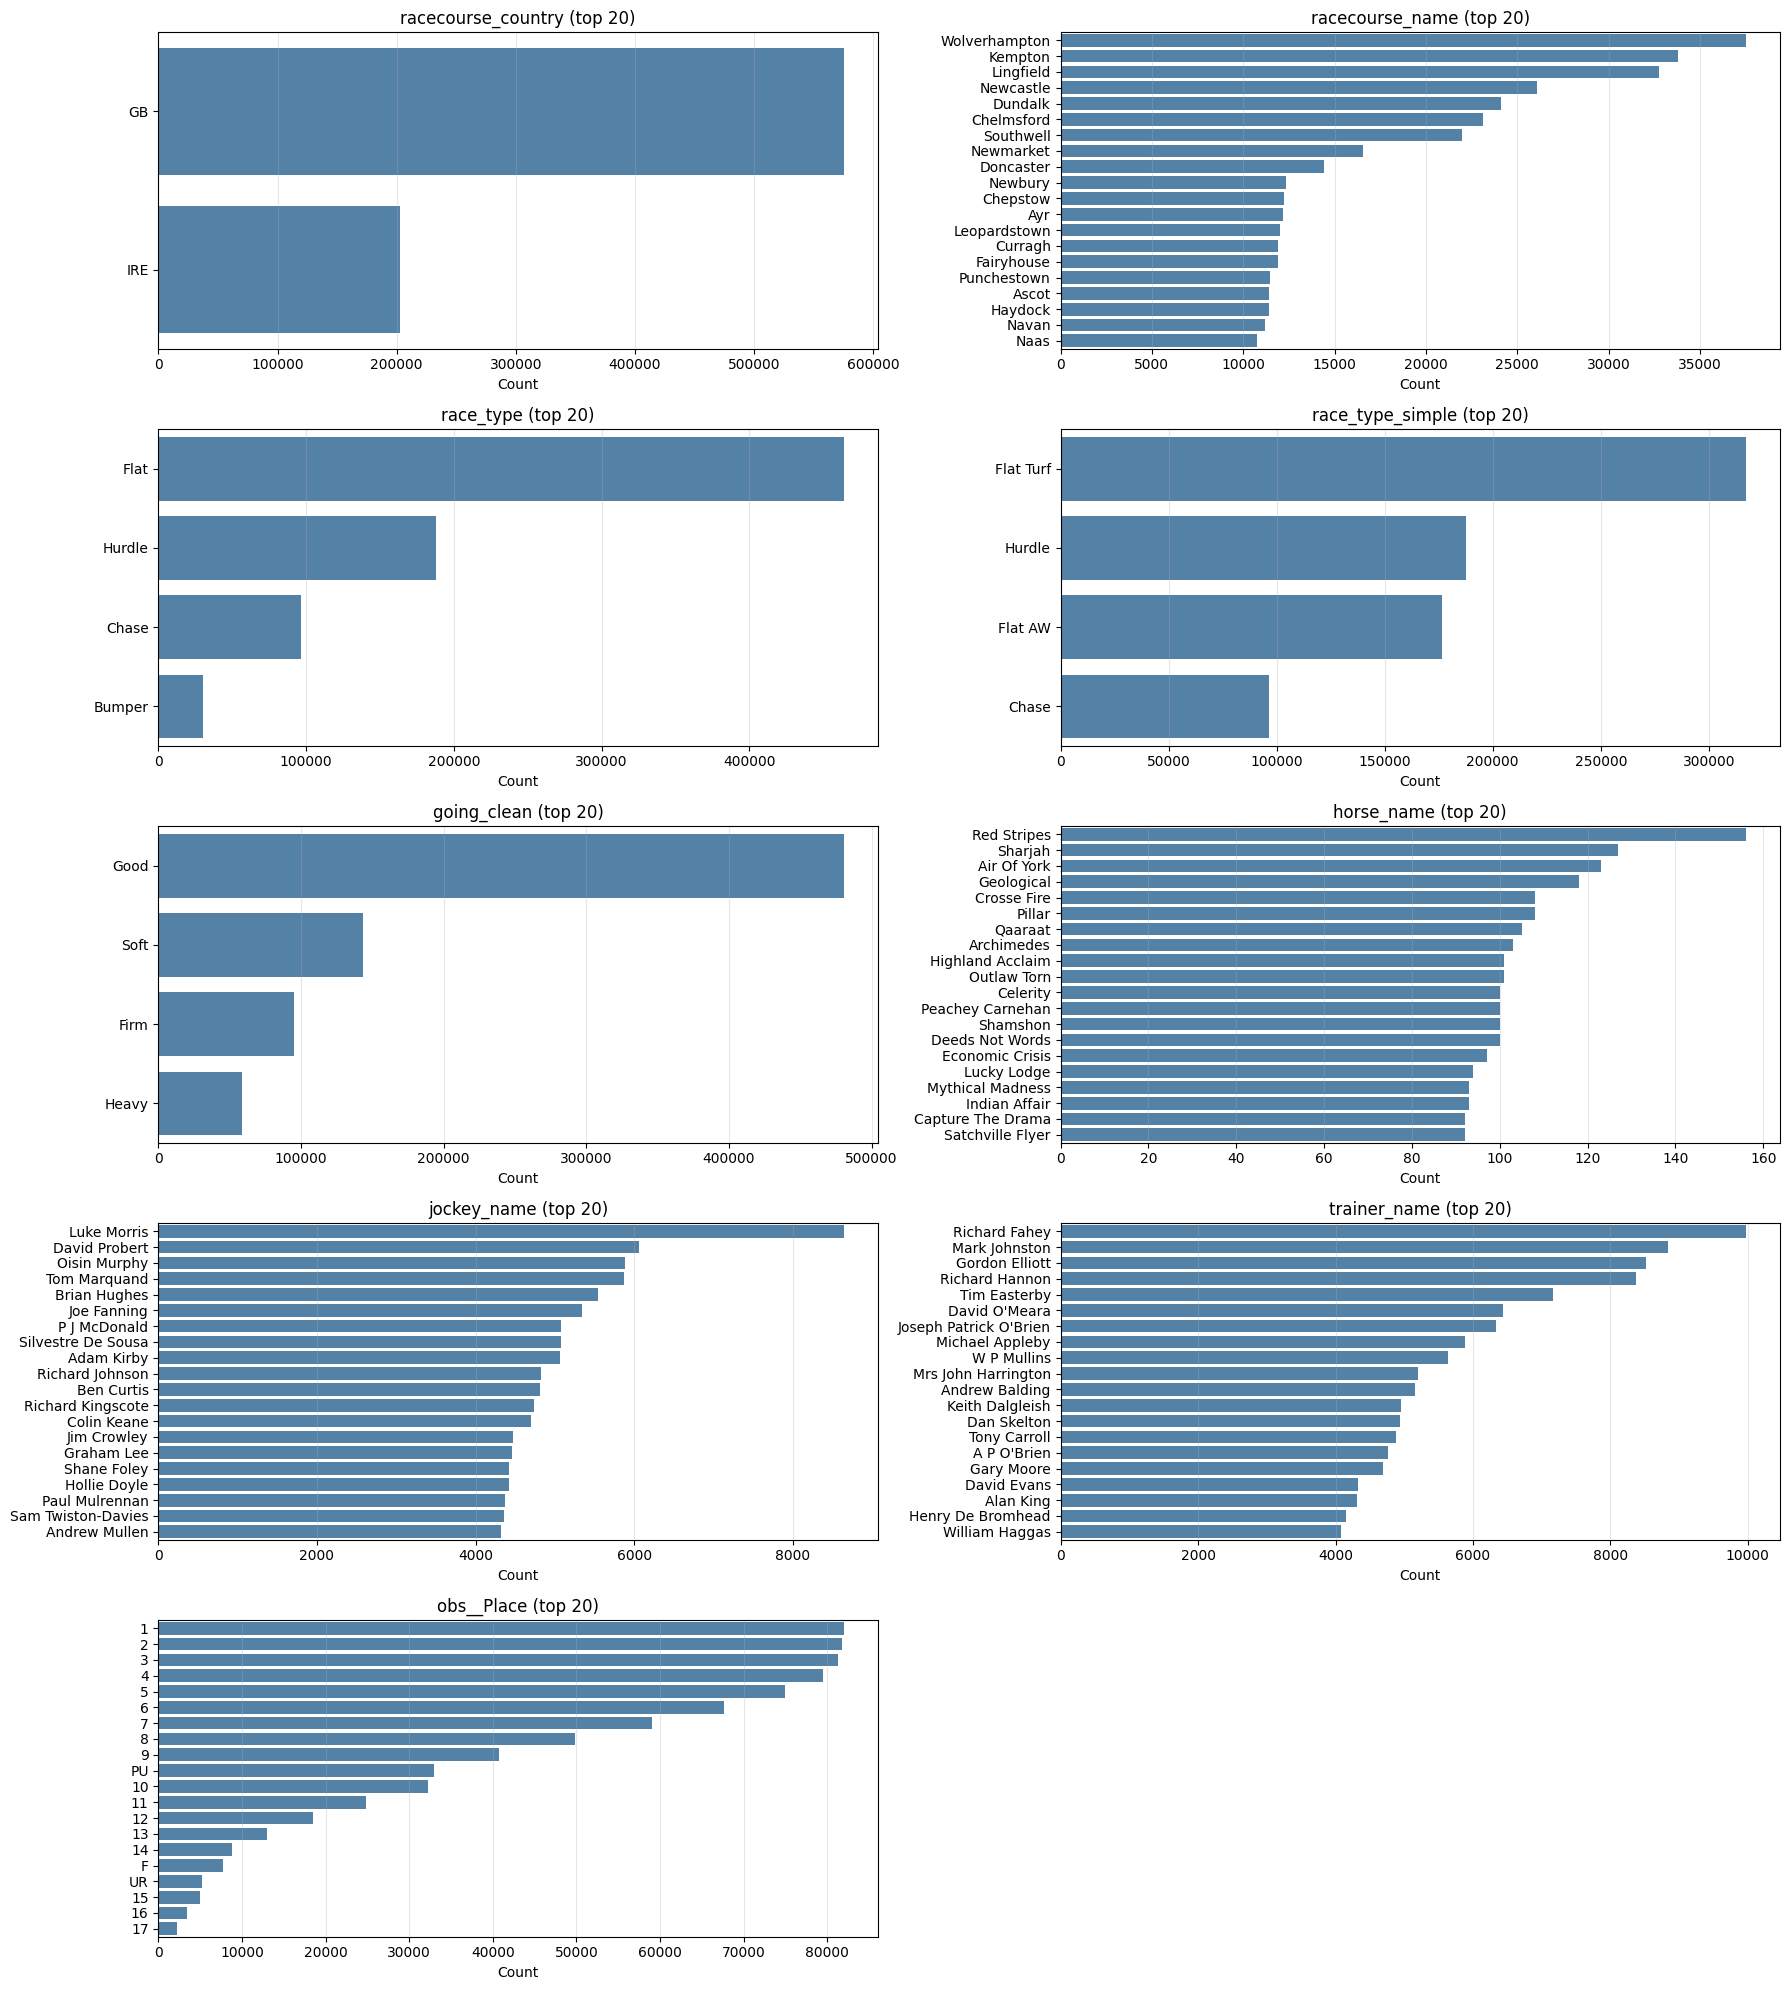

In [182]:
# identify categorical columns (object or category dtype)
cat_cols_all = df.select_dtypes(include=["object", "category"]).columns.tolist()

# exclude time-like and date columns that shouldn't be plotted as categories
cat_cols = [c for c in cat_cols_all if c not in ("race_time", "date")]

if len(cat_cols) == 0:
    print("no categorical columns found to plot.")
else:
    # limit number of categories shown per plot for readability
    top_n = 20
    
    # calculate grid dimensions: 2 columns per row
    n = len(cat_cols)
    cols_per_row = 2
    nrows = math.ceil(n / cols_per_row)

    # create subplot grid
    fig, axes = plt.subplots(nrows=nrows, ncols=cols_per_row, figsize=(18, max(3, nrows) * 4))
    axes = np.array(axes).reshape(-1)

    # plot horizontal bar chart for each categorical column
    for i, col in enumerate(cat_cols):
        # get value counts (including NaN) and limit to top N categories
        vc = df[col].value_counts(dropna=False).head(top_n)
        
        # create horizontal bar chart
        sns.barplot(x=vc.values, y=vc.index.astype(str), ax=axes[i], color="steelblue")
        axes[i].set_title(f"{col} (top {top_n})")
        axes[i].set_xlabel("Count")
        axes[i].set_ylabel("")
        axes[i].grid(True, axis="x", alpha=0.3)

    # hide any unused subplot axes
    for j in range(len(cat_cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

### categorical distributions: key observations and interpretations

- some categories are dominated
    - several categorical fields show clear leaders (for example, a small number of race types or countries account for most rows). This concentration suggests strong baseline effects tied to the most common categories.
    - the simplified race type categories appear well‑represented and will be useful as a primary race‑type feature.

- I will one hot encode categorical features and potentially just use names for plotting as I am given IDs

- string values appear in finishing places, these could be explored.

- data quality
    - Inconsistent casing/whitespace can inflate category counts; just to be safe I will standardize lowercase and strip whitespace for consitency

#### check for outliers across all numeric columns

In [183]:
# select numeric columns (excluding IDs and obs__ columns for this check)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if not col.endswith('_id') and not col.startswith('obs__')]

def detect_upper_outliers_iqr(series):
    """
    Detect upper outliers using the IQR (Interquartile Range) method.
    Returns outlier statistics (upper-only).
    
    Upper outliers are defined as values > Q3 + 1.5 * IQR
    """
    # calculate quartiles and interquartile range
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    # define upper bound for outliers
    upper_bound = Q3 + 1.5 * IQR
    
    # identify outliers above upper bound
    outlier_mask = series > upper_bound
    n_outliers = outlier_mask.sum()
    pct_outliers = (n_outliers / len(series)) * 100

    return {
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers,
        'upper_bound': upper_bound,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'max_outlier': series[outlier_mask].max() if n_outliers > 0 else None
    }

# check each numeric column for upper outliers
outlier_summary = []

for col in numeric_cols:
    # skip columns with more than 50% missing values
    if df[col].isna().sum() / len(df) > 0.5:
        continue
    
    # calculate outlier statistics for this column
    stats = detect_upper_outliers_iqr(df[col].dropna())
    
    # store summary information
    outlier_summary.append({
        'column': col,
        'n_outliers': stats['n_outliers'],
        'pct_outliers': f"{stats['pct_outliers']:.2f}%",
        'upper_bound': f"{stats['upper_bound']:.2f}",
        'max_outlier': f"{stats['max_outlier']:.2f}" if stats['max_outlier'] is not None else 'N/A'
    })

# create dataframe and sort by number of outliers (descending)
outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)

# display full outlier summary
print("Upper Outlier Summary (using IQR method):")
display(outlier_df)

# highlight columns with high outlier rates (>5%)
high_outlier_cols = outlier_df[outlier_df['pct_outliers'].str.rstrip('%').astype(float) > 5.0]
if not high_outlier_cols.empty:
    print("\n\nColumns with >5% upper outliers:")
    display(high_outlier_cols)


Upper Outlier Summary (using IQR method):


,column,n_outliers,pct_outliers,upper_bound,max_outlier
6,ltp_5min,105725,13.62%,79.50,1000.00
1,n_runners,15912,2.05%,20.50,40.00
5,draw,5415,0.70%,17.50,37.00
3,official_rating,1673,0.29%,157.50,177.00
2,age,611,0.08%,13.00,18.00
0,race_distance,564,0.07%,6541.16,6907.38
4,carried_weight,0,0.00%,87.77,N/A




Columns with >5% upper outliers:


,column,n_outliers,pct_outliers,upper_bound,max_outlier
6,ltp_5min,105725,13.62%,79.50,1000.00


outlier detection is crucial for understanding the reliability and distribution of numeric features in the dataset. The summary tables above uses the IQR (interquartile range) to flag unusually high values.

- most numeric columns have a small percentage of outliers**, less than 5%. this suggests the data is generally well-behaved, with only some extreme values in `ltp_5min`.
- `ltp_5min` (betting odds) stands out with a high proportion of outliers**. these are likely legitimate longshot odds rather than data errors, so they will be retained for modeling.
- No evidence of data entry errors or implausible values among flagged outliers. most extreme values are consistent with real-world racing scenarios.

overall, outlier analysis supports keeping the full range of values for modeling..

#### box plots to visualize outliers

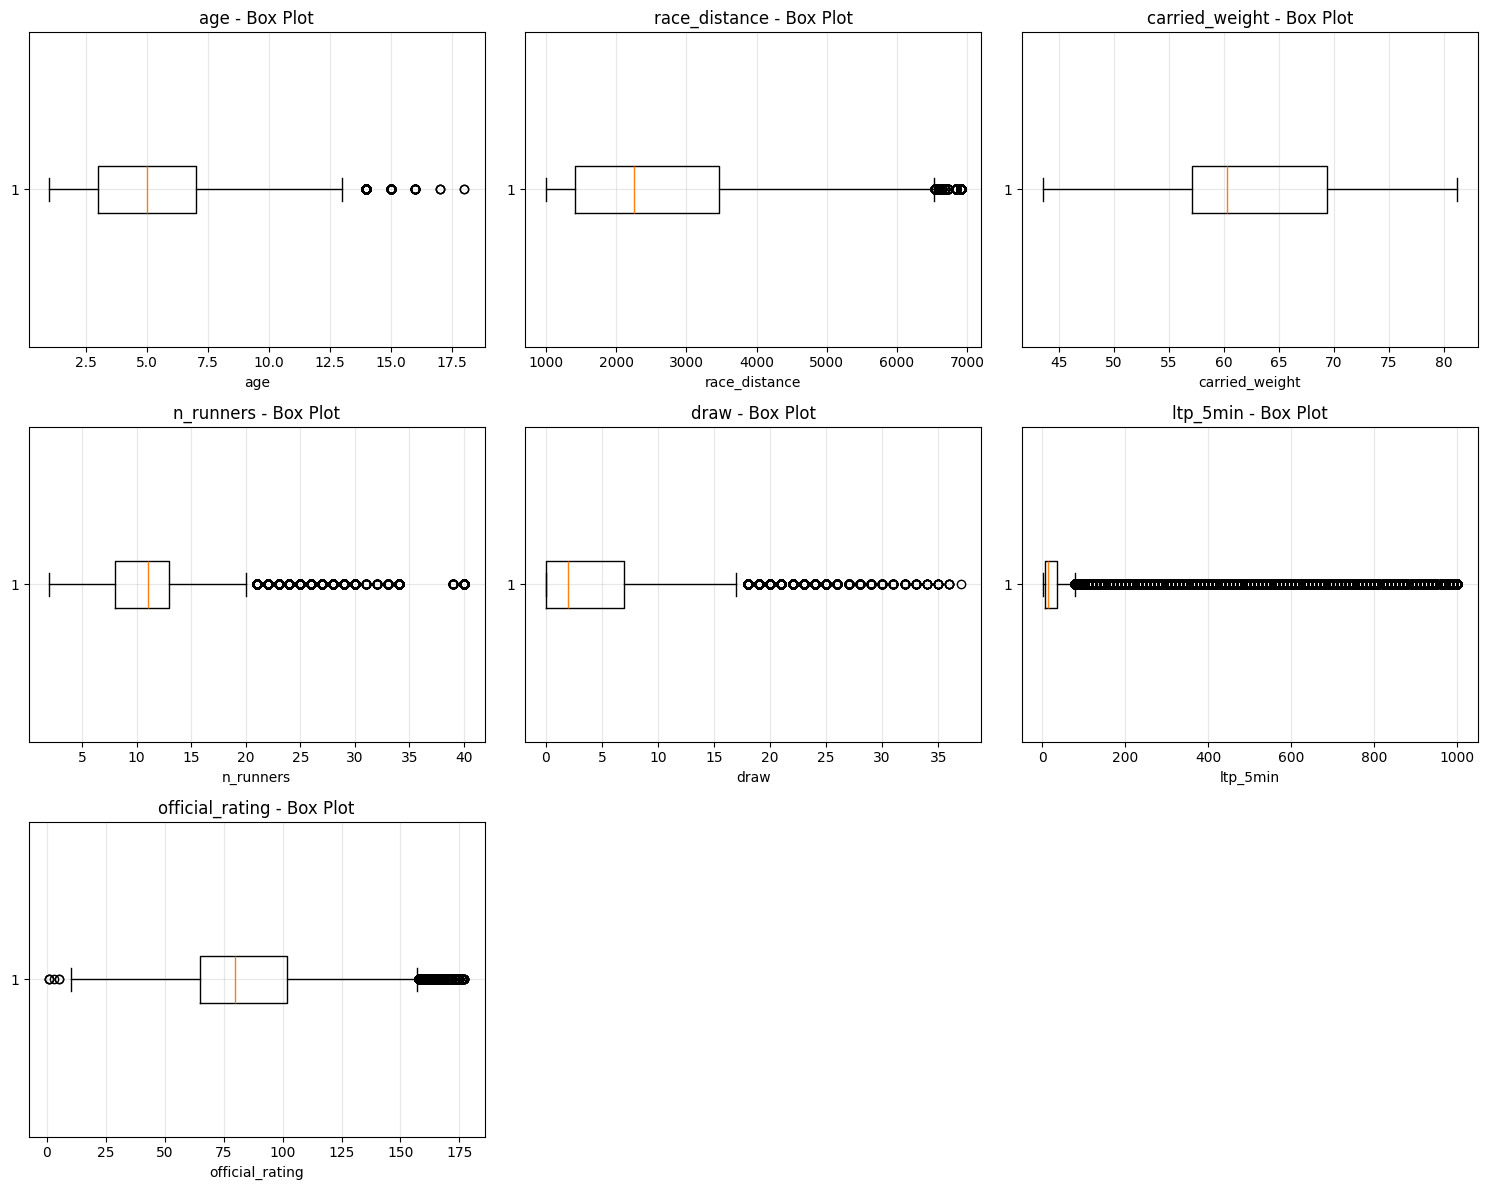

In [184]:
# visualizing outliers with box plots
key_cols = ['age', 'race_distance', 'carried_weight', 'n_runners', 'draw', 
            'ltp_5min', 'official_rating']

# filter to columns that exist in the dataframe
key_cols = [col for col in key_cols if col in df.columns]

# calculate grid dimensions: 3 columns per row
fig, axes = plt.subplots(nrows=(len(key_cols) + 2) // 3, ncols=3, figsize=(15, 4 * ((len(key_cols) + 2) // 3)))
axes = axes.flatten()

# create box plot for each column
for i, col in enumerate(key_cols):
    ax = axes[i]
    
    # drop missing values before plotting
    data = df[col].dropna()
    
    # create horizontal box plot
    ax.boxplot(data, vert=False)
    ax.set_xlabel(col)
    ax.set_title(f'{col} - Box Plot')
    
    # add light grid for readability
    ax.grid(True, alpha=0.3)

# hide any unused subplot axes (when total columns < grid cells)
for j in range(len(key_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### log-Transformed box plot of `ltp_5min` (very skewed)

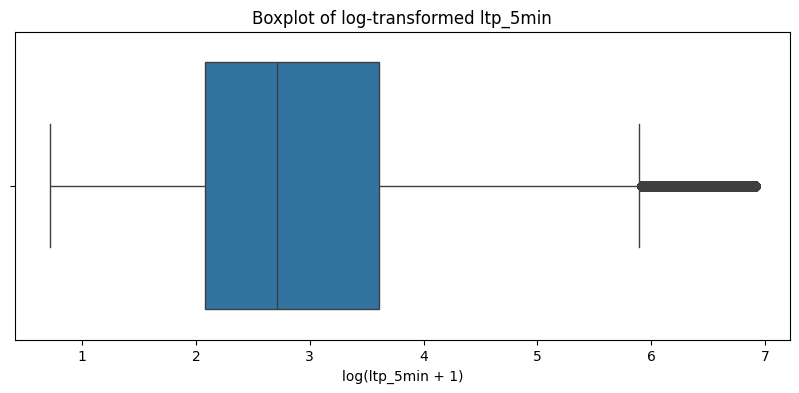

In [185]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df["ltp_5min"]))  # log transform for readability
plt.title("Boxplot of log-transformed ltp_5min")
plt.xlabel("log(ltp_5min + 1)")
plt.show()

there are many high values, but they look expected rather than a few isolated outliers.
Since `ltp_5min` (the last traded price 5 minutes before the off) should be a strong predictor, and only a relatively small number of rows are missing this value, I will drop rows where `ltp_5min` is missing rather than fill the missing values. I will also log-transform `ltp_5min` for stability when using it as a model input.

#### descriptive statistics

In [186]:
# descriptive statistics for numeric columns
print("numeric columns descriptive statistics")

numeric_cols_all = df.select_dtypes(include=[np.number]).columns
desc_stats = df[numeric_cols_all].describe()
display(desc_stats)

numeric columns descriptive statistics


,race_id,race_distance,n_runners,horse_id,age,official_rating,carried_weight,draw,jockey_id,trainer_id,ltp_5min,obs__bsp,obs__racing_post_rating,obs__uposition,obs__is_winner,obs__top_speed,obs__distance_to_winner,obs__pos_prize,obs__completion_time
count,777549.000000,777549.000000,777549.000000,777549.000000,777549.000000,573933.000000,777549.000000,777549.000000,777549.000000,777549.0000,776013.000000,777549.000000,712937.000000,777549.000000,777549.000000,613980.000000,777549.000000,777549.000000,729807.000000
mean,109715.692889,2576.181522,10.922081,82528.762396,5.111508,84.482016,62.940441,3.749681,8641.737704,557.2796,57.562299,64.618670,74.780498,5.961040,0.105213,50.133003,13.843247,1648.562300,178.525863
std,61586.714991,1262.509887,3.995936,64900.547393,2.318795,25.583146,6.810474,4.408433,16411.299575,632.5196,148.671556,163.297245,29.183750,3.896173,0.306827,27.501326,13.891333,9359.561244,105.368744
min,28.000000,1000.353600,2.000000,1.000000,1.000000,1.000000,43.544868,0.000000,5.000000,1.0000,1.050000,1.030000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,54.000000
25%,59382.000000,1409.090400,8.000000,27889.000000,3.000000,65.000000,57.152639,0.000000,982.000000,123.0000,7.000000,7.000000,55.000000,3.000000,0.000000,30.000000,2.750000,0.000000,88.530000
50%,92420.000000,2253.081600,11.000000,69863.000000,5.000000,80.000000,60.327785,2.000000,3885.000000,405.0000,14.000000,14.500000,73.000000,5.000000,0.000000,48.000000,8.300000,280.000000,133.710000
75%,162331.000000,3461.918400,13.000000,137989.000000,7.000000,102.000000,69.399633,7.000000,9613.000000,836.0000,36.000000,37.350000,94.000000,8.000000,0.000000,67.000000,21.800000,962.500000,259.810000
max,215837.000000,6907.377600,40.000000,311690.000000,18.000000,177.000000,81.193034,37.000000,311367.000000,11162.0000,1000.000000,1001.000000,181.000000,40.000000,1.000000,177.000000,40.000000,921537.500000,614.090000


## key insights from descriptive statistics

- **race distance:** wide range, reflecting diverse race types.
- **number of runnerss:** most races have 7–15 runners; some reach 40
- **age:** average age of competing horses is 5
- **official rating:** mean and median values are relatively close around 80, which could be a good baseline for feature enginerring jockey/trainer ratings later
- **draw postion:** some races have more runners than stalls, indicating races without stalls.
- **betting odds (`ltp_5min`):** extreme longshots present which skew the data as show with the meanv value much larger then median, imputing missing values wouldnt make sense
- **data quality:** no duplicates or constant columns; missing values for model input features in `official_rating` and `ltp_5min`. Several numeric features show strong skew and high variance, which supports using transformations later on.
The summary statistics inform preprocessing and feature engineering choices.


#### pairplot visualization of key numeric variables

creating pairplot with 7 variables using 5000 samples...
variables: age, race_distance, carried_weight, n_runners, draw, ltp_5min, official_rating


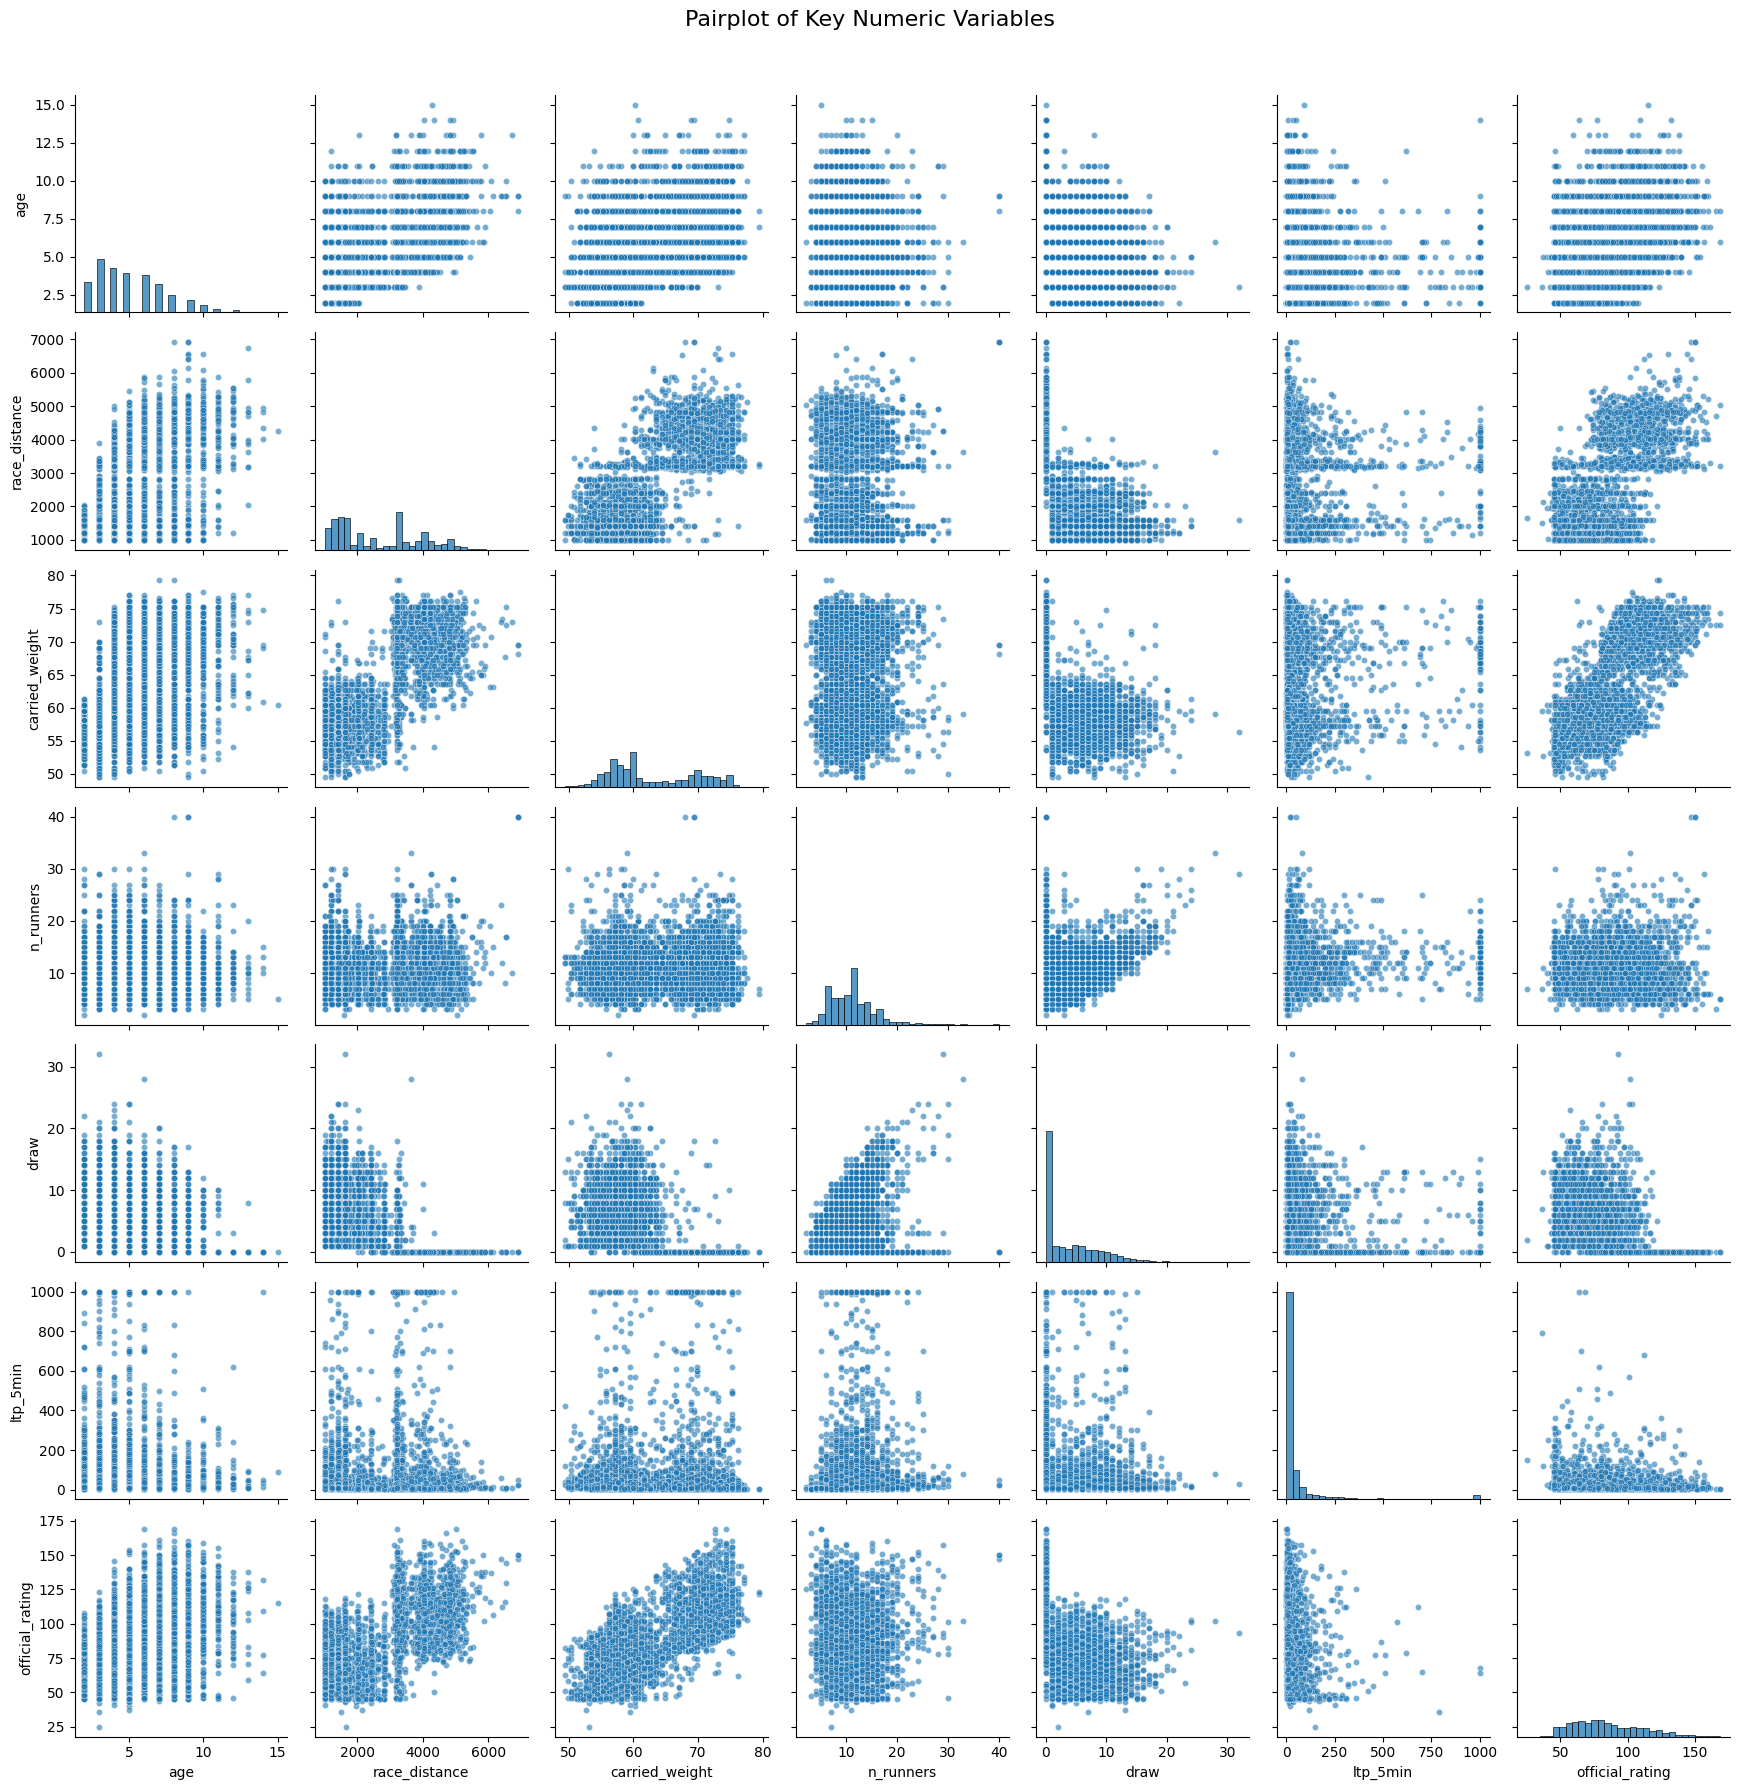

In [187]:
# select key numeric columns for pairplot (excluding ids and obs__ columns)
# using a subset to keep the visualization manageable
pairplot_cols = [
    'age', 
    'race_distance', 
    'carried_weight', 
    'n_runners', 
    'draw',
    'ltp_5min',
    'official_rating'
]

# filter to columns that exist in the dataframe
pairplot_cols = [col for col in pairplot_cols if col in df.columns]

# take a sample for faster plotting (adjust sample size as needed)
# for full dataset, remove the sample line
sample_size = min(5000, len(df))  # use max 5000 rows for performance
df_sample = df[pairplot_cols].sample(n=sample_size, random_state=42)

print(f"creating pairplot with {len(pairplot_cols)} variables using {sample_size} samples...")
print(f"variables: {', '.join(pairplot_cols)}")

# create pairplot
sns.pairplot(df_sample, 
             diag_kind='hist',  # histogram on diagonal
             plot_kws={'alpha': 0.6, 's': 20},  # scatter plot styling
             diag_kws={'bins': 30})  # histogram binning

plt.suptitle('Pairplot of Key Numeric Variables', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## key insights from pairplot analysis

the pairplot reveals important relationships between numeric variables:

- Most pairs show little to no linear correlation, suggesting independent predictive signals
- some pairs seem to have a monotonic relationship, such as `carried_weight` and `official_rating`

**Scatter plot patterns:**
- no strong outlier clusters or data quality issues visible
- `ltp_5min` vs other variables seems to be the most dispersed, possibly indicating market uncertainty
- `draw` shows discrete vertical bands (whole number stall positions) with dense cluster at 0

**Modeling implications:**
- variables appear mostly independent, minimizing multicollinearity concerns
- `ltp_5min` will benefit from log transformation for modeling
- `draw` may need separate treatment for stall vs non-stall races
- no obvious interaction terms emerge from visual inspection, even though race type-specific effects may exist

The pairplot confirms that the numeric features capture different aspects of racing performance and will contribute complementary information to the predictive model.

#### correlation heatmap for numeric variables

correlation matrix for key numeric variables:


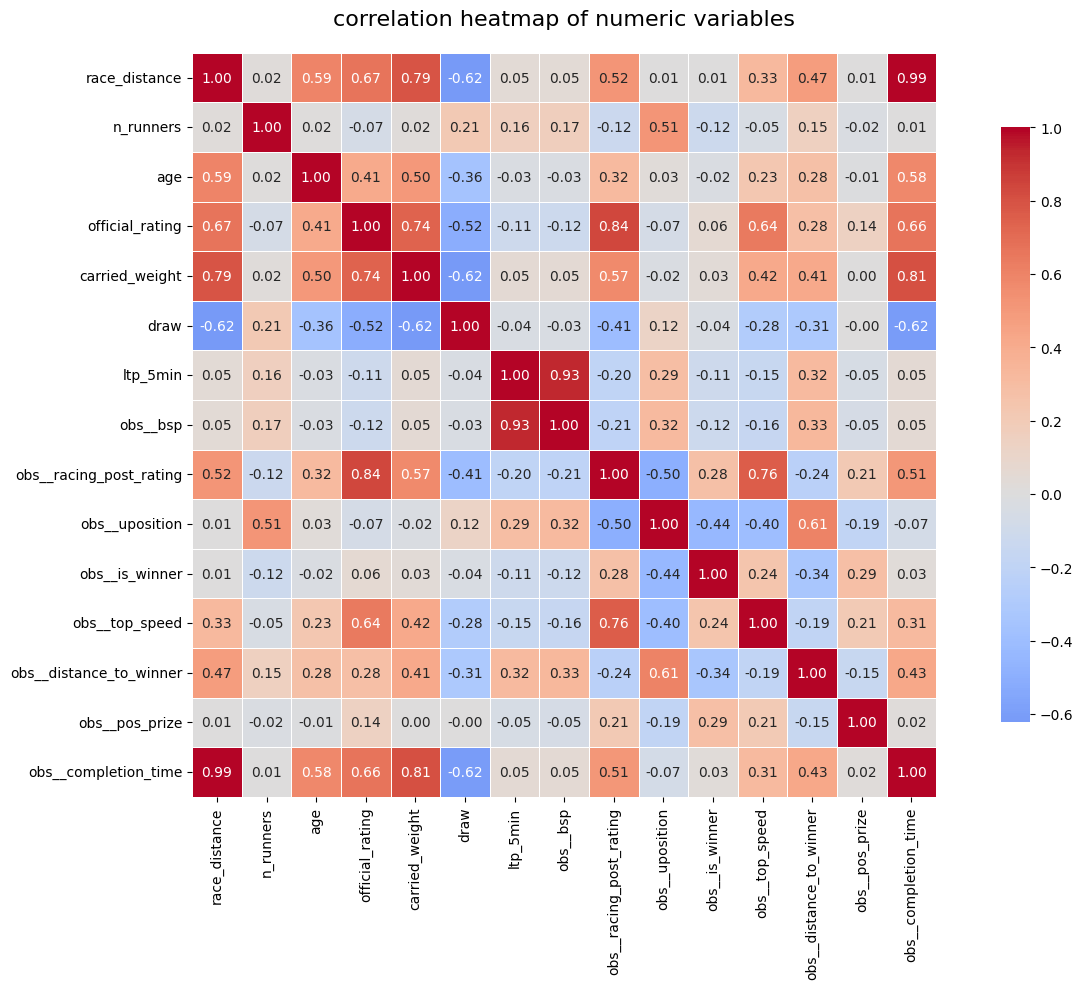



most correlated feature pairs (|correlation| > 0.6):


,feature_1,feature_2,correlation
10,race_distance,obs__completion_time,0.992167
5,ltp_5min,obs__bsp,0.934715
6,official_rating,obs__racing_post_rating,0.835460
12,carried_weight,obs__completion_time,0.808010
1,race_distance,carried_weight,0.792306
8,obs__racing_post_rating,obs__top_speed,0.756827
2,official_rating,carried_weight,0.739218
0,race_distance,official_rating,0.665727
11,official_rating,obs__completion_time,0.664746
7,official_rating,obs__top_speed,0.638842


In [188]:
print("correlation matrix for key numeric variables:")

# select numeric columns excluding ids
corr_cols = [col for col in numeric_cols_all if not col.endswith('_id')]

# calculate correlation matrix
correlation_matrix = df[corr_cols].corr()

# create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, 
            annot=True,  # show correlation values
            fmt='.2f',   # format to 2 decimal places
            cmap='coolwarm',  # color scheme
            center=0,    # center colormap at 0
            square=True,  # make cells square
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('correlation heatmap of numeric variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# print the most correlated feature pairs
print("\n\nmost correlated feature pairs (|correlation| > 0.6):")

# get upper triangle of correlation matrix to avoid duplicates
upper_tri = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# find correlations above threshold
high_corr = []
for column in upper_tri.columns:
    for index in upper_tri.index:
        corr_value = upper_tri.loc[index, column]
        if pd.notna(corr_value) and abs(corr_value) > 0.6:
            high_corr.append({
                'feature_1': index,
                'feature_2': column,
                'correlation': corr_value
            })

# sort by absolute correlation value
high_corr_df = pd.DataFrame(high_corr).sort_values('correlation', key=abs, ascending=False)

if not high_corr_df.empty:
    display(high_corr_df)
else:
    print("no feature pairs with |correlation| > 0.6 found")

### Correlation results: key relationships and implications

- strong mechanical/time relationships
    - race_distance vs obs__completion_time: very high positive correlation (~0.99). longer races take longer; expected and confirms timing consistency.
    - carried_weight vs obs__completion_time: strong positive (~0.81). heavier weights associate with longer completion times, likely reflecting fatigue or handicap effects.

- ability and performance signals
    - official_rating vs obs__racing_post_rating: strong positive (~0.84). official and Racing Post ratings align closely; both capture similar underlying ability.
    - official_rating vs obs__top_speed: strong positive (~0.64). higher rated horses tend to record higher top speeds.
    - obs__racing_post_rating vs obs__top_speed: strong positive (~0.76). post race ratings track speed well, reinforcing its usefulness for evaluation.

- field position and outcomes
    - obs__uposition vs obs__distance_to_winner: strong positive (~0.61). worse finishing positions correspond to larger distances behind the winner; consistent with race dynamics.
    - obs__racing_post_rating vs obs__uposition: strong negative (~-0.50). better ratings associate with better finishing positions (lower numbers).

- market-related relationships
    - ltp_5min vs obs__bsp: very strong positive (~0.93). last traded price aligns closely with Betfair starting price, indicating consistent market valuation.
    - ltp_5min has weak-to-moderate correlations with most performance variables, suggesting it captures independent market sentiment beyond simple linear relationships with features.

#### investigate missing values of `official_rating`

In [189]:
# overall missing rate for official_rating
overall_missing = df["official_rating"].isna().mean()
print("overall missing rate for official_rating:", overall_missing)

# missing rate by age
missing_by_age = (
    df["official_rating"]
      .isna()
      .groupby(df["age"])
      .mean()
      .sort_index()
)
print("\nmissing rate for official_rating by age:\n", missing_by_age)

# proportion of horses that never have an official_rating in any race
horse_missing_mask = (
    df["official_rating"]
      .isna()
      .groupby(df["horse_id"])
      .all()       # true if the horse is never rated in any run
)

horse_never_rated = horse_missing_mask.mean()
print("\nproportion of horses that are never officially rated:", horse_never_rated)

overall missing rate for official_rating: 0.2618690269037707

missing rate for official_rating by age:
 age
1     1.000000
2     0.702608
3     0.251901
4     0.243740
5     0.325123
6     0.225945
7     0.127372
8     0.073479
9     0.047904
10    0.037231
11    0.029678
12    0.035059
13    0.038337
14    0.069038
15    0.098039
16    0.153846
17    0.000000
18    0.000000
Name: official_rating, dtype: float64

proportion of horses that are never officially rated: 0.25311597458442975


many missing `official_rating` values belong to horses that appear to be unrated (often younger or less exposed horses).

filling these missing values with overall mean (or even age-specific means) would create artificial ratings for unrated horses, which is not realistic.

for now, `official_rating` will be left alone as is and the missing values will be handled later during feature engineering in Q2.

#### check if names map to multiple IDs (ex. same name reused for different horses)

In [190]:
name_to_horse_counts = df.groupby("horse_name")["horse_id"].nunique()
name_to_jockey_counts = df.groupby("jockey_name")["jockey_id"].nunique()
name_to_trainer_counts = df.groupby("trainer_name")["trainer_id"].nunique()

print("Horse names mapping to multiple IDs:\n", name_to_horse_counts.value_counts())
print("\nJockey names mapping to multiple IDs:\n", name_to_jockey_counts.value_counts())
print("\nTrainer names mapping to multiple IDs:\n", name_to_trainer_counts.value_counts())

Horse names mapping to multiple IDs:
 horse_id
1    77681
2      112
Name: count, dtype: int64

Jockey names mapping to multiple IDs:
 jockey_id
1    2514
2      71
Name: count, dtype: int64

Trainer names mapping to multiple IDs:
 trainer_id
1    2439
2       1
Name: count, dtype: int64


several horse, jockey and trainer names are reused for different ID's (ex. different horses with the same name). The ID's can be treated as categorical features or used to derive ratings.

#### compare `race_type` and `race_type_simple`

In [191]:
print(df["race_type"].value_counts())
print("\n", df["race_type_simple"].value_counts())

race_type
Flat      463683
Hurdle    187572
Chase      96249
Bumper     30045
Name: count, dtype: int64

 race_type_simple
Flat Turf    317096
Hurdle       187572
Flat AW      176632
Chase         96249
Name: count, dtype: int64


Because the question focuses on `race_type_simple`, I will treat this as the main race type feature, but will also keep `race_type` in case a more detailed analysis of subtypes (chase and bumper) is needed.

## summary stats for numeric columns and draw vs number of runners

In [192]:
# numeric columns excluding IDs
num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols[~num_cols.str.endswith("_id")]

df[num_cols].describe()

,race_distance,n_runners,age,official_rating,carried_weight,draw,ltp_5min,obs__bsp,obs__racing_post_rating,obs__uposition,obs__is_winner,obs__top_speed,obs__distance_to_winner,obs__pos_prize,obs__completion_time
count,777549.000000,777549.000000,777549.000000,573933.000000,777549.000000,777549.000000,776013.000000,777549.000000,712937.000000,777549.000000,777549.000000,613980.000000,777549.000000,777549.000000,729807.000000
mean,2576.181522,10.922081,5.111508,84.482016,62.940441,3.749681,57.562299,64.618670,74.780498,5.961040,0.105213,50.133003,13.843247,1648.562300,178.525863
std,1262.509887,3.995936,2.318795,25.583146,6.810474,4.408433,148.671556,163.297245,29.183750,3.896173,0.306827,27.501326,13.891333,9359.561244,105.368744
min,1000.353600,2.000000,1.000000,1.000000,43.544868,0.000000,1.050000,1.030000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,54.000000
25%,1409.090400,8.000000,3.000000,65.000000,57.152639,0.000000,7.000000,7.000000,55.000000,3.000000,0.000000,30.000000,2.750000,0.000000,88.530000
50%,2253.081600,11.000000,5.000000,80.000000,60.327785,2.000000,14.000000,14.500000,73.000000,5.000000,0.000000,48.000000,8.300000,280.000000,133.710000
75%,3461.918400,13.000000,7.000000,102.000000,69.399633,7.000000,36.000000,37.350000,94.000000,8.000000,0.000000,67.000000,21.800000,962.500000,259.810000
max,6907.377600,40.000000,18.000000,177.000000,81.193034,37.000000,1000.000000,1001.000000,181.000000,40.000000,1.000000,177.000000,40.000000,921537.500000,614.090000


#### check races where the number of runners exceeds the maximum draw

In [193]:
rows_over_37 = df[df["n_runners"] > 37].copy()

print("Number of rows with n_runners > 37:", len(rows_over_37))
print("\nRace types for these rows:\n", rows_over_37["race_type"].value_counts())
print("\nSimplified race types:\n", rows_over_37["race_type_simple"].value_counts())
print("\nNumber of such races:\n", rows_over_37["race_id"].value_counts())

Number of rows with n_runners > 37: 199

Race types for these rows:
 race_type
Chase    199
Name: count, dtype: int64

Simplified race types:
 race_type_simple
Chase    199
Name: count, dtype: int64

Number of such races:
 race_id
142015    40
142128    40
142207    40
142265    40
141959    39
Name: count, dtype: int64


summary statistics show that `n_runners` can be as high as 40, while `draw` only goes up to 37. The cases with more than 37 runners occur in chase-type races, where stalls are typically not used. This explains the mismatch between `n_runners` and `draw`.

I will keep both `n_runners` and `draw` for now, later when building the model, I might scale draw by its field size which is more interpretable across different field sizes and race types.

#### check object columns with mixed numeric / non-numeric values

In [194]:
mixed_type_cols = []
all_numeric_cols = []
all_nonnumeric_cols = []

for col in df.select_dtypes(include="object").columns:
    numeric = pd.to_numeric(df[col], errors="coerce")
    
    if numeric.notna().any() and numeric.isna().any():
        mixed_type_cols.append(col)
    elif numeric.notna().any() and not numeric.isna().any():
        all_numeric_cols.append(col)
    elif not numeric.notna().any() and numeric.isna().any():
        all_nonnumeric_cols.append(col)

print("Columns with mixed numeric and non-numeric values:", mixed_type_cols)
print("Columns that are numeric but stored as object:", all_numeric_cols)
print("Columns with only non-numeric values:", all_nonnumeric_cols)

numeric_dtype_cols = df.select_dtypes(include="number").columns.tolist()
print("\nColumns already numeric:", numeric_dtype_cols)

Columns with mixed numeric and non-numeric values: ['obs__Place']
Columns that are numeric but stored as object: []
Columns with only non-numeric values: ['date', 'racecourse_country', 'racecourse_name', 'race_time', 'race_type', 'race_type_simple', 'going_clean', 'horse_name', 'jockey_name', 'trainer_name']

Columns already numeric: ['race_id', 'race_distance', 'n_runners', 'horse_id', 'age', 'official_rating', 'carried_weight', 'draw', 'jockey_id', 'trainer_id', 'ltp_5min', 'obs__bsp', 'obs__racing_post_rating', 'obs__uposition', 'obs__is_winner', 'obs__top_speed', 'obs__distance_to_winner', 'obs__pos_prize', 'obs__completion_time']


`obs__Place` is the only column that mixes numeric values (finishing positions) and non-numeric incident codes (ur, f, dsq, ...). Since `obs__Place` is used for evaluation rather than as a model input, I will keep everything as is so I dont lose any information about incident outcomes.

#### quick check of incident codes vs win flag

In [195]:
# Common incident codes for place
special_places = ["bd", "co", "dsq", "f", "lft", "pu", "ref", "ro", "rr", "su", "ur"]

# Rows where obs__Place has one of those incident codes
place_filter = df["obs__Place"].isin(special_places)

# Total number of incident rows
n_incidents = place_filter.sum()
print("Total rows with an incident:", n_incidents)

# Check whether any incident rows are marked as winners
incident_and_win = df[place_filter & (df["obs__is_winner"] == 1)]
print("Number of rows with an incident and a recorded win:", len(incident_and_win))

# Show a small sample of incident rows
sample_rows = (
    df[place_filter]
    .groupby("obs__Place")
    .head(2)[["age", "n_runners", "obs__Place", "obs__uposition"]]
)

display(sample_rows)

Total rows with an incident: 0
Number of rows with an incident and a recorded win: 0


,age,n_runners,obs__Place,obs__uposition


Incident codes such as `ur`, `f`, `dsq` indicate that the horse did not finish normally. These rows are never marked as winners which makes sense. The `obs__uposition` column records the finishing position, and appears consistent with these incident codes. Since these variables are primarily for evalution and descriptive analysis, I will leave them unchanged and not use them directly in the prediction model.

#### additional data quality checks

In [196]:
print("additional data quality checks:")

# check for negative values where they shouldn't exist
print("\n checking for negative values in non-negative columns:")
non_negative_cols = ['age', 'race_distance', 'carried_weight', 'n_runners', 'draw', 'ltp_5min']
for col in non_negative_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"{col} has {neg_count} negative values")
        else:
            print(f"{col}: no negative values")

# check for zero or extremely low values in ltp_5min (odds should be >= 1.01)
print("\n checking ltp_5min validity (odds should be >= 1.01):")
low_odds = (df['ltp_5min'] < 1.01).sum()
if low_odds > 0:
    print(f"{low_odds} rows have ltp_5min < 1.01")
    print(f"   Min value: {df['ltp_5min'].min()}")
else:
    print(f"all ltp_5min values are >= 1.01")

# check for unrealistic age values
print("\n checking for unrealistic age values:")
age_range = df['age'].describe()[['min', 'max']]
print(f"   Age range: {age_range['min']} to {age_range['max']}")
if age_range['min'] < 1 or age_range['max'] > 20:
    print(f"some ages may be unrealistic for horse racing")
else:
    print(f"age range appears reasonable")

# check for draw values consistency with race type
print("\n checking draw values by race type:")
draw_by_race_type = df.groupby('race_type_simple')['draw'].agg(['count', 'min', 'max', lambda x: x.isna().sum()])
draw_by_race_type.columns = ['count', 'min_draw', 'max_draw', 'missing']
print(draw_by_race_type)

# data shape
print(f"\n dataset shape: {df.shape}") # rows, columns

additional data quality checks:

 checking for negative values in non-negative columns:
age: no negative values
race_distance: no negative values
carried_weight: no negative values
n_runners: no negative values
draw: no negative values
ltp_5min: no negative values

 checking ltp_5min validity (odds should be >= 1.01):
all ltp_5min values are >= 1.01

 checking for unrealistic age values:
   Age range: 1.0 to 18.0
age range appears reasonable

 checking draw values by race type:
                   count  min_draw  max_draw  missing
race_type_simple                                     
Chase              96249         0         0        0
Flat AW           176632         0        20        0
Flat Turf         317096         0        37        0
Hurdle            187572         0         0        0

 dataset shape: (777549, 30)


## Data Preprocessing

now based on all of the above EDA I will bgein to preprocess the data so it is prepped for modeling

#### convert the `date` and `race_time` columns to proper datetime types and sort the dataset chronologically. this is important later when I create a time-based train–test split.

In [197]:
df["date"] = pd.to_datetime(df["date"])
df["race_time"] = pd.to_datetime(df["race_time"], format="%H:%M").dt.time

# sort races in chronological order
df = df.sort_values(["date", "race_time"]).reset_index(drop=True)

#### convert string columns to lowercase and strip any white space. this avoids accidental duplication of categories due to case or trailing spaces

In [198]:
# standardize string columns: lowercase and strip whitespace
for col in df.select_dtypes(include="object").columns:
    # race_time is stored as an object but already treated as time, so skip it
    if col != "race_time":
        df[col] = df[col].str.strip().str.lower()

#### drop rows where `ltp_5min` is missing

In [199]:
df = df.dropna(subset=["ltp_5min"]).reset_index(drop=True)
print("Shape after dropping rows with missing ltp_5min:", df.shape)

Shape after dropping rows with missing ltp_5min: (776013, 30)


#### drop name columns and keep ID's

In [200]:
cols_to_drop = ["horse_name", "jockey_name", "trainer_name"]
df = df.drop(columns=cols_to_drop)

print("\nColumns after dropping name columns:\n", df.columns)
print("New shape:", df.shape)


Columns after dropping name columns:
 Index(['date', 'racecourse_country', 'racecourse_name', 'race_time', 'race_id',
       'race_distance', 'race_type', 'race_type_simple', 'going_clean',
       'n_runners', 'horse_id', 'age', 'official_rating', 'carried_weight',
       'draw', 'jockey_id', 'trainer_id', 'ltp_5min', 'obs__bsp',
       'obs__racing_post_rating', 'obs__Place', 'obs__uposition',
       'obs__is_winner', 'obs__top_speed', 'obs__distance_to_winner',
       'obs__pos_prize', 'obs__completion_time'],
      dtype='object')
New shape: (776013, 27)


#### additional preprocessing

In [201]:
# handle any data quality issues found

# from EDA, ltp_5min is heavily right-skewed with high outliers
# these could be legitimate longshot odds

# create a flag for extreme longshots (odds > 100), this is mainly created for exploratory understanding
# it may or may not be useful downstream since modleing will already use ltp_5min.
df['is_longshot'] = (df['ltp_5min'] > 100).astype(int)
print(f"\nNumber of longshots (odds > 100): {df['is_longshot'].sum()}")
print(f"Percentage: {(df['is_longshot'].sum() / len(df)) * 100:.2f}%")

# handle draw values for chase/hurdle races where stalls aren't used
# From EDA, chase races have missing draws
print(f"\nMissing draw values by race type:")
print(df.groupby('race_type_simple')['draw'].apply(lambda x: x.isna().sum()))

# for races without stalls (chase/hurdle), and because draw starts at 1, fill missing draws with 0
# this way, the model knows these races don't have draw advantage
df['draw'] = df['draw'].fillna(0)
print(f"\nAfter filling: Missing draw values = {df['draw'].isna().sum()}")


# Create additional useful features from existing data
print("\ncreating additional features:")

# draw position as percentage of field size (more interpretable)
df['draw_pct'] = df['draw'] / df['n_runners']
df['draw_pct'] = df['draw_pct'].fillna(0)  # for chase races with no draw draw_pct becomes 0
print(f"created 'draw_pct' (draw position as % of field size)")

# log transformed ltp_5min for better modeling (heavily skewed)
df['log_ltp_5min'] = np.log1p(df['ltp_5min'])
print(f"created 'log_ltp_5min' (log-transformed odds)")

print("\ndataset shape:", df.shape)


Number of longshots (odds > 100): 82398
Percentage: 10.62%

Missing draw values by race type:
race_type_simple
chase        0
flat aw      0
flat turf    0
hurdle       0
Name: draw, dtype: int64

After filling: Missing draw values = 0

creating additional features:
created 'draw_pct' (draw position as % of field size)
created 'log_ltp_5min' (log-transformed odds)

dataset shape: (776013, 30)


#### summary of preprocessing decisions based on EDA

**key preprocessing steps completed:**

 **missing values handled:**
   - dropped rows with missing `ltp_5min` as it should be a critical predictor
   - `official_rating` will be handled in Q2 using historical information within each horse's past runs (not means)
   - `draw` is  filled with 0 for chase/hurdle races (no stalls used)

 **data type conversions:**
   - `date` converted to datetime
   - `race_time` converted to time object
   - string columns standardized (lowercase, stripped whitespace)

 **outliers assessed:**
   - high `ltp_5min` values are legitimate longshots, kept as-is
   - created `is_longshot` flag for odds > 100
   - other numeric outliers appear reasonable for horse racing data

 **feature engineering (preliminary):**
   - `draw_pct`: draw position as % of field size (handles variable field sizes)
   - `log_ltp_5min`: log-transformed odds (handles heavy right skew)

 **data integrity:**
   - no duplicate rows found
   - no constant columns
   - name columns dropped in favor of stable IDs
   - data sorted chronologically for time-based splits

**next steps:**
- Q1: analyze peak age by race type
- Q2: build rating systems for horses, jockeys, trainers
- Q3: build predictive model
- Q4: compare to betting market

# Q1. Explore the peak age of horses
- for each race_type_simple, analyze horse performance by age.
- identify and report the peak performance age.

Note: incident rows(ur, f, dsq,...) in `obs__Place` are kept, so the results reflect overall "real-world" performance, not just clean completions.

#### create per race type subsets

In [202]:
# Create one DataFrame per race_type_simple for easier analysis
flat_turf_df = df[df["race_type_simple"] == "flat turf"].copy()
flat_aw_df   = df[df["race_type_simple"] == "flat aw"].copy()
hurdle_df    = df[df["race_type_simple"] == "hurdle"].copy()
chase_df     = df[df["race_type_simple"] == "chase"].copy()

print("Flat turf shape:", flat_turf_df.shape)
print("Flat AW shape:  ", flat_aw_df.shape)
print("Hurdle shape:   ", hurdle_df.shape)
print("Chase shape:    ", chase_df.shape)

Flat turf shape: (316505, 30)
Flat AW shape:   (176240, 30)
Hurdle shape:    (187117, 30)
Chase shape:     (96151, 30)


#### function to summarize performance by age

In [203]:
def age_performance_summary(race_df, min_runs=1000):
    """
    summarize performance by age for a given race-type subset.
    Only ages with at least "min_runs" are kept to make the summary more reliable.
    """
    summary = (
        race_df
        .groupby("age")
        .agg(
            number_of_runs=("horse_id", "size"),
            avg_post_rating=("obs__racing_post_rating", "mean"),
            average_finish_pos=("obs__uposition", "mean"),
            win_rate=("obs__is_winner", "mean"),
            avg_top_speed=("obs__top_speed", "mean"),
            avg_distance_to_winner=("obs__distance_to_winner", "mean"),
            avg_time_to_complete=("obs__completion_time", "mean"),
        )
        .reset_index()
    )

    # Report any ages with too few runs
    few_runs = summary[summary["number_of_runs"] < min_runs][["age", "number_of_runs"]]
    if not few_runs.empty:
        print(f"ages excluded (number_of_runs < {min_runs}):")
        print(few_runs)
    else:
        print(f"all ages have at least {min_runs} runs.")

    # Keep only ages with enough runs
    summary = summary[summary["number_of_runs"] >= min_runs]

    return summary

A threshold of 1000 runs per age is used to ensure that peak-age estimates are based on sufficiently large samples, this is feasible given the size of the dataset and will exclude under represented ages

#### function to print peak ages for key metrics

In [204]:
def print_peak_metrics(summary):
    """
    print the age that performs best for each metric
    within a prepared summary DataFrame.
    """
    # Highest post-race rating
    best_post_age = summary.loc[summary["avg_post_rating"].idxmax(), "age"]
    print("age with highest avg_post_rating:", best_post_age)

    # Lowest average finish position (lower is better)
    best_finish_age = summary.loc[summary["average_finish_pos"].idxmin(), "age"]
    print("age with lowest average_finish_pos:", best_finish_age)
    # Highest win rate
    best_win_age = summary.loc[summary["win_rate"].idxmax(), "age"]
    print("age with highest win_rate:", best_win_age)

    # Highest top speed
    best_speed_age = summary.loc[summary["avg_top_speed"].idxmax(), "age"]
    print("age with highest avg_top_speed:", best_speed_age)
    # Lowest average distance to winner
    best_dist_age = summary.loc[summary["avg_distance_to_winner"].idxmin(), "age"]
    print("age with lowest avg_distance_to_winner:", best_dist_age)

    # Lowest completion time
    best_time_age = summary.loc[summary["avg_time_to_complete"].idxmin(), "age"]
    print("age with lowest avg_time_to_complete:", best_time_age)

where multiple ages are close, I still report the single best age per metric but I'd comment on neighboring ages when interpreting peak age bands

#### apply the summary and peak-age functions for each race type

In [205]:
# use min_runs = 1000 so only trust ages with enough data
print("Flat turf:")
summary_ft = age_performance_summary(flat_turf_df, min_runs=1000)
display(summary_ft)
print_peak_metrics(summary_ft)

print("\nFlat AW:")
summary_aw = age_performance_summary(flat_aw_df, min_runs=1000)
display(summary_aw)
print_peak_metrics(summary_aw)

print("\nHurdle:")
summary_h = age_performance_summary(hurdle_df, min_runs=1000)
display(summary_h)
print_peak_metrics(summary_h)

print("\nChase:")
summary_chase = age_performance_summary(chase_df, min_runs=1000)
display(summary_chase)
print_peak_metrics(summary_chase)

Flat turf:
ages excluded (number_of_runs < 1000):
    age  number_of_runs
0     1               1
10   11             997
11   12             374
12   13              76
13   14              22
14   15              11
15   16               5


,age,number_of_runs,avg_post_rating,average_finish_pos,win_rate,avg_top_speed,avg_distance_to_winner,avg_time_to_complete
1,2,56247,61.978927,5.721852,0.108984,43.192538,8.133111,82.525779
2,3,96361,64.255899,5.791108,0.115223,43.610289,9.043423,110.357537
3,4,65392,69.074957,6.220470,0.101618,45.510771,10.679215,137.629628
4,5,43022,71.997613,6.134582,0.103970,46.867238,11.453587,152.466728
5,6,24055,68.515690,6.425234,0.086094,45.713148,10.908050,139.366397
6,7,14108,65.058628,6.503898,0.082790,44.145204,9.668252,124.644160
7,8,8531,62.645798,6.461845,0.077365,42.667691,8.968286,117.357937
8,9,4843,60.008188,6.605823,0.069791,40.822397,9.416199,117.817879
9,10,2460,57.066751,6.638211,0.064228,39.432556,9.452053,117.564048


age with highest avg_post_rating: 5
age with lowest average_finish_pos: 2
age with highest win_rate: 3
age with highest avg_top_speed: 5
age with lowest avg_distance_to_winner: 2
age with lowest avg_time_to_complete: 2

Flat AW:
ages excluded (number_of_runs < 1000):
    age  number_of_runs
9    11             807
10   12             314
11   13             101
12   14              10
13   15               7


,age,number_of_runs,avg_post_rating,average_finish_pos,win_rate,avg_top_speed,avg_distance_to_winner,avg_time_to_complete
0,2,24768,56.882194,5.708697,0.103238,37.353926,7.575678,86.253589
1,3,51631,58.612736,5.503477,0.115105,38.561321,7.628106,104.084847
2,4,36593,60.120100,5.758834,0.110595,39.632212,7.443612,110.980822
3,5,23156,61.634887,5.696191,0.107618,40.098322,7.142328,114.102108
4,6,15311,62.332324,5.797792,0.093723,40.292910,7.196202,114.640610
5,7,10443,61.557274,5.893038,0.082831,39.590413,7.339610,113.963252
6,8,6836,60.271189,5.955530,0.079140,38.306926,7.729498,115.146072
7,9,4156,56.948692,6.170115,0.071463,36.980426,8.054030,112.769498
8,10,2107,55.226238,6.236355,0.060750,35.534670,8.594589,115.739045


age with highest avg_post_rating: 6
age with lowest average_finish_pos: 3
age with highest win_rate: 3
age with highest avg_top_speed: 6
age with lowest avg_distance_to_winner: 5
age with lowest avg_time_to_complete: 2

Hurdle:
ages excluded (number_of_runs < 1000):
    age  number_of_runs
10   13             467
11   14             132
12   15              26
13   16               6
14   18               2


,age,number_of_runs,avg_post_rating,average_finish_pos,win_rate,avg_top_speed,avg_distance_to_winner,avg_time_to_complete
0,3,4867,85.503357,5.793713,0.110951,56.968235,23.578652,252.875278
1,4,23282,88.688387,6.823297,0.085001,61.305596,23.988053,268.445392
2,5,47056,92.973256,6.332880,0.107085,63.288672,22.437155,288.945555
3,6,44789,94.734492,6.194601,0.113465,64.445222,21.500394,300.553193
4,7,28417,93.701577,6.358835,0.096984,64.030796,21.765324,306.608708
5,8,17095,93.234448,6.502603,0.085522,63.171814,22.192159,311.226862
6,9,10695,91.463194,6.560542,0.081066,62.180306,22.548892,314.155549
7,10,5954,90.380032,6.674337,0.071045,60.991884,23.120331,317.832229
8,11,3003,86.979409,6.866800,0.063603,57.709073,24.002897,320.653224
9,12,1326,82.896646,7.242836,0.055053,55.718213,25.158597,323.894911


age with highest avg_post_rating: 6
age with lowest average_finish_pos: 3
age with highest win_rate: 6
age with highest avg_top_speed: 6
age with lowest avg_distance_to_winner: 6
age with lowest avg_time_to_complete: 3

Chase:
ages excluded (number_of_runs < 1000):
    age  number_of_runs
0     4             599
10   14             313
11   15              57
12   16              13
13   17               3


,age,number_of_runs,avg_post_rating,average_finish_pos,win_rate,avg_top_speed,avg_distance_to_winner,avg_time_to_complete
1,5,4752,106.694215,4.990320,0.140783,75.370653,21.851441,309.915273
2,6,15109,109.702661,4.813092,0.162486,75.875143,20.644748,323.176919
3,7,21648,108.858028,5.053631,0.142877,74.529019,21.377575,332.636953
4,8,19214,107.447127,5.327313,0.123816,73.429103,22.237980,341.281489
5,9,14535,105.266339,5.564981,0.107121,71.807899,23.140065,346.099056
6,10,10082,102.681631,5.665939,0.094922,69.824181,23.487304,349.355675
7,11,5690,101.147871,5.813884,0.085413,68.021781,24.552680,356.213275
8,12,2935,95.945822,5.927768,0.078024,64.648315,25.381755,360.333757
9,13,1201,92.824385,5.959201,0.067444,63.972414,25.489675,359.657352


age with highest avg_post_rating: 6
age with lowest average_finish_pos: 6
age with highest win_rate: 6
age with highest avg_top_speed: 6
age with lowest avg_distance_to_winner: 6
age with lowest avg_time_to_complete: 5


the tables above show how performance varies by age for each race type, using several metrics.

I restrict to ages with at least 1,000 runs to avoid drawing conclusions from very small samples.

#### plot win rate by age for each race type

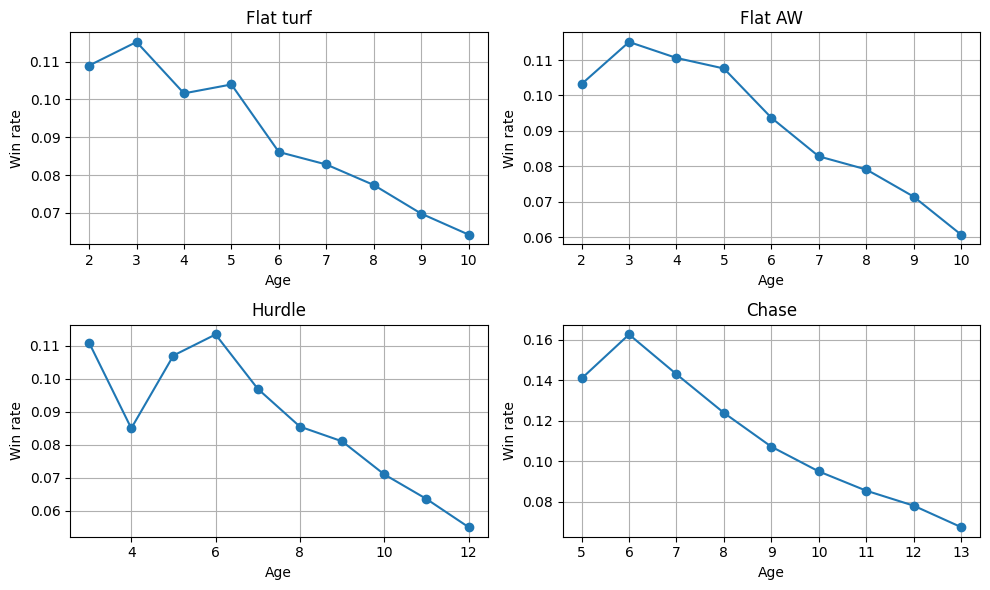

In [206]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.plot(summary_ft["age"], summary_ft["win_rate"], marker="o")
plt.title("Flat turf")
plt.xlabel("Age")
plt.ylabel("Win rate")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(summary_aw["age"], summary_aw["win_rate"], marker="o")
plt.title("Flat AW")
plt.xlabel("Age")
plt.ylabel("Win rate")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(summary_h["age"], summary_h["win_rate"], marker="o")
plt.title("Hurdle")
plt.xlabel("Age")
plt.ylabel("Win rate")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(summary_chase["age"], summary_chase["win_rate"], marker="o")
plt.title("Chase")
plt.xlabel("Age")
plt.ylabel("Win rate")
plt.grid(True)

plt.tight_layout()
plt.show()

these plots focus on win rate, which is the most intuitive performace measure.
- Flat (turf and AW) win rates tend to peak around younger ages (3 years old).
- Hurdle and Chase win rates shift slightly towards older horses (around 6 years old), which fits intuitions that jumpers might mature later.


incident rows are still included in this analysis. this makes the summaries reflect "real-word" performance, including jockey error and jumping mistakes, rather than only clean finishes.

#### check incident rates by race type

In [207]:
# Reuse the special_places list from earlier
special_places = ["bd", "co", "dsq", "f", "lft", "pu", "ref", "ro", "rr", "su", "ur"]

# Rows with an incident in obs__Place
place_filter = df["obs__Place"].isin(special_places)

incident_rows = (
    df[place_filter]
    .groupby("race_type_simple")
    .size()
    .rename("n_incident_rows")
)

total_rows = (
    df.groupby("race_type_simple")
      .size()
      .rename("n_rows")
)

incident_summary = (
    pd.concat([total_rows, incident_rows], axis=1)
    .fillna(0)
)

incident_summary["incident_rate"] = incident_summary["n_incident_rows"] / incident_summary["n_rows"]

display(incident_summary)

,n_rows,n_incident_rows,incident_rate
race_type_simple,,,
chase,96151,21777,0.226488
flat aw,176240,706,0.004006
flat turf,316505,1665,0.005261
hurdle,187117,23721,0.126771


incident rates are low in flat races and higher in chase races. There are no rows where an incident and a win occur together.

removing all incident rows would artificially inflate win rates in certain age groups and race types. keeping them gives a more realistic view of performance that includes both physical ability and error/behavior risk.

different metrics (speed, distance to winner, completion time) can point to slightly different "peek" ages, depending on what aspect of performance is of interest. here, win rate provides a simple and intuitive summary to answer the question.

# Q2. Feature engineering: Build a rating for each horse, jockey and trainer
- Construct a rating system for horses, jockeys and trainers based only on past performance data (i.e. excluding future information and
obs__* variables from the current race).

**Do not use any obs__* variables as direct predictors, since these are only known after the race starts. You can use past values
though. You may also use them for evaluation where relevant.

## Horse rating: repaired `official_rating`

- use `official_rating` as the main horse rating
- for each horse:
    - if the first ever race has `official_rating` missing, set it to 0 (unrated)
    - for later races, if `official_rating` is missing, fill it using the best rating seen so far for that horse:
        - prefer PAST `obs__racing_post_rating` if available.
        - otherwise fall back to previous `official_rating`

** I will only ever use information from pasat races for that horse, therefore no data leakage. **

In [208]:
import numpy as np

# mark the first race per horse (data is already sorted by date and race_time)
df["is_first_race_for_horse"] = df.groupby("horse_id").cumcount() == 0

# for first races with missing official_rating, set to 0 (unrated horses)
first_race_missing_mask = (
    df["is_first_race_for_horse"] &
    df["official_rating"].isna()
)

df.loc[first_race_missing_mask, "official_rating"] = 0

print(
    "number of first-race official_ratings set to 0:",
    first_race_missing_mask.sum()
)

# fill remaining missing official_rating using past "best rating" for each horse
filled_from_history = 0

for horse_id, idx in df.groupby("horse_id").groups.items():
    last_best = None  # best rating seen so far for this horse

    # idx is a list of row positions for this horse, in time order
    for i in idx:
        cur_official = df.at[i, "official_rating"]
        cur_post = df.at[i, "obs__racing_post_rating"]

        # if official_rating is missing and there is a past rating, fill it
        if pd.isna(cur_official) and last_best is not None:
            df.at[i, "official_rating"] = last_best
            filled_from_history += 1
            cur_official = last_best

        # update last_best using this race, for future races
        if not pd.isna(cur_post):
            last_best = cur_post
        elif not pd.isna(cur_official):
            last_best = cur_official

print(
    "number of official_ratings filled from historical best rating:",
    filled_from_history
)

# check that no official_rating values remain missing
remaining_missing = df["official_rating"].isna().sum()
print("rows still missing official_rating:", remaining_missing)

# clean up helper column
df = df.drop(columns=["is_first_race_for_horse"])

# quick summary of the final official_rating distribution
df["official_rating"].describe()

number of first-race official_ratings set to 0: 64432
number of official_ratings filled from historical best rating: 138151
rows still missing official_rating: 0


count    776013.000000
mean         74.949835
std          34.520159
min           0.000000
25%          57.000000
50%          76.000000
75%          98.000000
max         177.000000
Name: official_rating, dtype: float64

I repaired `official_rating` without using future information, so that each horse has a realistic rating in every race.

## shared incident codes (used for jockey and trainer ratings)

In [209]:
# incident codes in obs__Place that are treated as negative outcomes
incident_codes = {"bd", "co", "dsq", "f", "lft", "pu", "ref", "ro", "rr", "su", "ur"}

## Jockey Rating
- I will start each jockey with a rating of 75, the reason I chose this value is because it was close to the horses' mean/median official_rating before repair

    this keeps the ratings for jockey to a similar scale as official_rating and based on the rules im placing and the way the rating should evolves over time, it should carry a realistic signal for a model.
    - the feature `jockey_rating` stores the current rating before the race.
    - after the race, I update the rating based on the outcome:
        - incident is a penalty
        - win is a reward
        - 2nd/3rd is a small reward
        - last or near last are penalties
- ratings are capped between 0 and 200

In [210]:
# create a column to store the jockey's rating before each race
df["jockey_rating"] = np.nan

start_rating_jockey = 75  # starting rating for all jockeys

for jockey_id, idx in df.groupby("jockey_id").groups.items():
    rating = start_rating_jockey

    for i in idx:
        # store current rating as the feature for this race (depends only on past races)
        df.at[i, "jockey_rating"] = rating

        # outcome of this race
        place_val = df.at[i, "obs__Place"]
        upos_val = df.at[i, "obs__uposition"]
        n_runners = df.at[i, "n_runners"]

        delta = 0  # change to rating from this race

        # convert place to string so I can check incident codes
        place_str = str(place_val)

        if place_str in incident_codes:
            # incidents get a penalty
            delta = -6
        else:
            pos = int(upos_val)
            n = int(n_runners)

            if pos == 1:
                delta = +5
            elif pos in (2, 3):
                delta = +2
            elif pos == n:
                delta = -5
            elif pos >= max(n - 4, 1):
                # In the last 5 places
                delta = -1
            else:
                delta = 0  # mid-pack → no change

        # update rating for next race
        rating = rating + delta
        rating = max(0, min(200, rating))  # keep within [0, 200]

print(df["jockey_rating"].describe())
print("\nMissing jockey ratings:", df["jockey_rating"].isna().sum())

count    776013.000000
mean         87.578457
std          78.267078
min           0.000000
25%           8.000000
50%          68.000000
75%         181.000000
max         200.000000
Name: jockey_rating, dtype: float64

Missing jockey ratings: 0


the `jockey_rating` feature summarizes each jockey's past performance at the time of each race.
- ratings start at 75 and evolve race by race.
- incidents and poor finishing postitions reduce the ratings, wins and places increase it.
- the rating used as a feature for a race is always the value before that race, so it only depends on historical races for that jockey.

## Trainer Rating
- each trainer starts with a rating of 100 (slightly higher baseline to reflect experience, they could have possibly been a jockey before).
    - logic is similar to jockey rating but with slightly different adjustments:
        - incidents are penalized more heavily
        - wins and places give stronger rewards.
- again, the rating is stored before each race and updated after each race.

In [211]:
# Create a column to store the trainer's rating before each race
df["trainer_rating"] = np.nan

start_rating_trainer = 100  # starting rating for all trainers

for trainer_id, idx in df.groupby("trainer_id").groups.items():
    rating = start_rating_trainer

    for i in idx:
        # Store current rating as the feature for this race
        df.at[i, "trainer_rating"] = rating

        # Outcome of this race
        place_val = df.at[i, "obs__Place"]
        upos_val = df.at[i, "obs__uposition"]
        n_runners = df.at[i, "n_runners"]

        delta = 0  # change to rating from this race

        place_str = str(place_val)

        if place_str in incident_codes:
            # Incidents penalize trainers more heavily
            delta = -7
        else:
            pos = int(upos_val)
            n = int(n_runners)

            if pos == 1:
                delta = +6
            elif pos in (2, 3):
                delta = +3
            elif pos == n:
                delta = -5
            elif pos >= max(n - 4, 1):
                delta = -3
            else:
                delta = 0

        # Update rating for next race
        rating = rating + delta
        rating = max(0, min(200, rating))  # keep within [0, 200]

print(df["trainer_rating"].describe())
print("\nMissing trainer ratings:", df["trainer_rating"].isna().sum())

count    776013.000000
mean         63.125280
std          69.206707
min           0.000000
25%           3.000000
50%          31.000000
75%         107.000000
max         200.000000
Name: trainer_rating, dtype: float64

Missing trainer ratings: 0


the `trainer_rating` feature is constructed in a similar way to `jockey_rating`, but with different step sizes.
- trainers start at 100 and are rewarded more strongly for wins and good finishes.
- incidents and consistently poor finishes reduce the rating more, reflecting that trainers influence preparation and behavior.
- as with jockeys, the rating used in each race only depends on that trainer's previous races.

# Q3. Build a predictive model
- Build a predictive model for race winners using your ratings and other covariates (but excluding current race obs__* variables). Your
model could produce win probabilities for each runner that sum to 1 in each race for example.

My goal is to build a logistic regression model to predict binary race outcomes (win vs no win) and provide estimated win probabilities for each runner. After modelling, I will standardise the raw predicted probabilities within each race so that the probabilities over all runners in that race sum to 1.

I choose logistic regression instead of tree-based models such as Random Forests or XGBoost. Although those models often achieve higher raw predictive performance, and I would otherwise recommend them, they are more complex and are typically treated as “black-box” methods. Logistic regression is more interpretable and transparent, coefficients can be read as log-odds effects of each feature, making it easier to understand how factors contribute to the predicted win probability. Given the importance of explainability and model diagnostics in this context, I prioritise logistic regression over non-linear models like complex decision trees.

### train-val-test split (time-based)

In [212]:
# Time-based train / val / test split by date: 70% / 15% / 15%

n_rows = len(df)

# 70% and 85% cutoff indices
cutoff_idx_train = int(n_rows * 0.70)
cutoff_idx_val   = int(n_rows * 0.85)

cutoff_date_train = df.iloc[cutoff_idx_train]["date"]
cutoff_date_val   = df.iloc[cutoff_idx_val]["date"]

print("70% cutoff date (end of train):", cutoff_date_train)
print("85% cutoff date (end of val):  ", cutoff_date_val)

# Train = all races up to and including cutoff_date_train
train_df = df[df["date"] <= cutoff_date_train].copy()

# Val   = races after train up to and including cutoff_date_val
val_df   = df[(df["date"] > cutoff_date_train) & (df["date"] <= cutoff_date_val)].copy()

# Test  = races after cutoff_date_val
test_df  = df[df["date"] > cutoff_date_val].copy()

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("\nWhere training data ends:", train_df["date"].tail(1).values)
print("where val data starts:",      val_df["date"].head(1).values)
print("where val data ends:",        val_df["date"].tail(1).values)
print("where test data starts:",     test_df["date"].head(1).values)

print("\ntrain / val / test sizes:", len(train_df), len(val_df), len(test_df))


70% cutoff date (end of train): 2020-06-19 00:00:00
85% cutoff date (end of val):   2021-05-15 00:00:00

Where training data ends: ['2020-06-19T00:00:00.000000000']
where val data starts: ['2020-06-20T00:00:00.000000000']
where val data ends: ['2021-05-15T00:00:00.000000000']
where test data starts: ['2021-05-16T00:00:00.000000000']

train / val / test sizes: 543467 116267 116279


The data is already sorted by "date" and "race_time", so I create a 70/15/15 time-based split using "date". I split to have a validation set specifically for model calibration as this is extremely important to achieve reliabile probabilities, the probabilities are what will actually be of interest when I go to compare with obs__bsp, rather than just the binary classification itself.

- All model fitting will use the training set only.
- The val set is used for diagnostics and Calibration
- The test set is kept for final evaluation

#### class imbalance - are there alot more rows of losers?

Class imbalance is an important consideration for building a model that performs well and generalises reliably. Because the majority of runners in a race do not win, the dataset naturally contains many more rows for losers than winners.

Without addressing this imbalance, a model may learn to focus primarily on predicting the majority class, achieving superficially good accuracy while failing to identify meaningful win signals.

In [213]:
print("train class balance (proportions):\n",
      train_df["obs__is_winner"].value_counts(normalize=True))

print("\nval class balance (proportions):\n",
      val_df["obs__is_winner"].value_counts(normalize=True))

print("\ntest class balance (proportions):\n",
      test_df["obs__is_winner"].value_counts(normalize=True))

train class balance (proportions):
 obs__is_winner
0    0.893887
1    0.106113
Name: proportion, dtype: float64

val class balance (proportions):
 obs__is_winner
0    0.899817
1    0.100183
Name: proportion, dtype: float64

test class balance (proportions):
 obs__is_winner
0    0.893773
1    0.106227
Name: proportion, dtype: float64


As expected, the data is strongly imbalanced: for each race there is only one winner and many non-winners. To deal with this, I will use RandomUnderSampler (undersampling the majority class ie non winners) inside the training pipeline, and evaluate using AUC and log loss rather than accuracy.

Because RandomUnderSampler changes the effective class balance during training, I later use probability calibration on the original (imbalanced) validation set to recover well-calibrated probabilities

#### mutual information for feature selection

In [214]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# candidate features for MI
numeric_for_mi = [
    "race_distance",
    "n_runners",
    "age",
    "official_rating",
    "carried_weight",
    "draw",
    "ltp_5min",
    "draw_pct",
    "log_ltp_5min",
    "jockey_rating",
    "trainer_rating"
]

categorical_for_mi = [
    "racecourse_country",
    "racecourse_name",
    "race_type_simple",
    "going_clean",
    "horse_id",
    "jockey_id",
    "trainer_id",
    "is_longshot",
]

mi_feature_cols = numeric_for_mi + categorical_for_mi

# build X and y for MI on the training set
X_mi = train_df[mi_feature_cols].copy()
y_mi = train_df["obs__is_winner"].astype(int)

# encode categorical columns as integer codes
for col in categorical_for_mi:
    X_mi[col] = X_mi[col].astype("category").cat.codes

# mark which features are discrete
discrete_mask = [col in categorical_for_mi for col in X_mi.columns]

# compute mutual information scores
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=discrete_mask,
    random_state=24,
)

# put scores into a Series for easy viewing
mi_series = pd.Series(mi_scores, index=X_mi.columns)
mi_series = mi_series.sort_values(ascending=False)

print("mutual information between each feature and obs__is_winner:\n")
for feature_name in mi_series.index:
    score = mi_series[feature_name]
    print(f"{feature_name:<30} {score:.4f}")

mutual information between each feature and obs__is_winner:

horse_id                       0.0674
log_ltp_5min                   0.0577
ltp_5min                       0.0567
n_runners                      0.0159
trainer_id                     0.0130
age                            0.0120
jockey_id                      0.0112
is_longshot                    0.0104
trainer_rating                 0.0078
jockey_rating                  0.0071
official_rating                0.0066
carried_weight                 0.0053
draw                           0.0046
draw_pct                       0.0037
race_distance                  0.0020
racecourse_name                0.0011
racecourse_country             0.0006
race_type_simple               0.0003
going_clean                    0.0001


Its often helput to prioritise features with higher mutual information, especially if using more expensive training procedures such as a grid search for hyper parameter tuning.

mutual information scores for id's should be interpreted with caution, but they are still useful as categorical inputs capturing individual effects

It is also interesting to note that the `log_ltp_5min` returned stronger mutual information than the raw `ltp_5min` and `draw` stronger than `draw_pct`.

Therefore `log_ltp_5min` and `draw` will be retained as a model feature.


### choosing features for a logistic regression model

In [215]:
# final feature list for the predictive model

numeric_features = [
    "race_distance",
    "n_runners",
    "age",
    "official_rating",   # repaired horse rating
    "carried_weight",
    "draw",
    "log_ltp_5min",      # log transformed market odds before the race
    "jockey_rating",     # engineered
    "trainer_rating",    # engineered
]

categorical_features = [
    "racecourse_country",
    "racecourse_name",
    "race_type_simple",
    "going_clean",
    "horse_id",
    "jockey_id",
    "trainer_id",
    "is_longshot",
]

feature_cols = numeric_features + categorical_features

# build X and y for train, val, and test
X_train = train_df[feature_cols].copy()
y_train = train_df["obs__is_winner"].astype(int)

X_val   = val_df[feature_cols].copy()
y_val   = val_df["obs__is_winner"].astype(int)

X_test  = test_df[feature_cols].copy()
y_test  = test_df["obs__is_winner"].astype(int)

print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("X_test shape:",  X_test.shape)

X_train shape: (543467, 17)
X_val shape: (116267, 17)
X_test shape: (116279, 17)


#### preprocessing, RandomUnderSampler and logistic regression

building a single pipeline that
- scales numeric features
- one-hot encodes categorical features
- applies RandomUnderSampler to handle class imbalance
- fits a logistic regression

In [216]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline  # for preprocessing

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline  # for full pipeline with resampling

import numpy as np

# preprocessing for numeric features: standardize
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

# preprocessing for categorical features: one-hot encode
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# apply preprocessing to numeric and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# logistic regression with fixed hyperparameters
log_reg = LogisticRegression(
    max_iter=1000,
    penalty="l2",
    C=1.0,              # regularization strength
    solver="saga",      # good for large, sparse problems
    class_weight=None,  # imbalance handled by under-sampling
    random_state=24,
)

# full pipeline: preprocessing, under-sampling, logistic regression
best_clf = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("under", RandomUnderSampler(
        random_state=24,
        sampling_strategy="auto",
    )),
    ("model", log_reg),
])

# fit once on the training data
best_clf.fit(X_train, y_train)
print("model training complete")

model training complete


#### Hyperparameter Tuning: Regularization Strength (C)

the logistic regression above uses the default regularization strength `C=1.0`. rather than assuming this is optimal, I use `GridSearchCV` to search over a range of C values using 3-fold cross-validation scored by log loss on the training set only.

this is important because:
- too much regularization (small C) underfits and produces bland probabilities
- too little regularization (large C) overfits to the training data
- the right balance gives the best calibrated predictions on unseen data

In [217]:
from sklearn.model_selection import GridSearchCV

# search over regularization strength
param_grid = {"model__C": [0.001, 0.01, 0.1, 1.0, 10, 100]}

grid_search = GridSearchCV(
    estimator=best_clf,
    param_grid=param_grid,
    scoring="neg_log_loss",
    cv=3,
    refit=True,
    n_jobs=-1,
    verbose=1,
)

# increase max_iter for stronger regularization values that converge slower
best_clf.named_steps["model"].max_iter = 5000
grid_search.fit(X_train, y_train)

# results
print(f"\nbest C: {grid_search.best_params_['model__C']}")
print(f"best CV log loss: {-grid_search.best_score_:.4f}\n")

# show all C values and their CV scores
import pandas as pd
cv_results = pd.DataFrame({
    "C": param_grid["model__C"],
    "mean_log_loss": [-s for s in grid_search.cv_results_["mean_test_score"]],
    "std_log_loss": grid_search.cv_results_["std_test_score"],
})
print(cv_results.to_string(index=False))

# update best_clf with the tuned model
best_clf = grid_search.best_estimator_
print(f"\nbest_clf updated with C={grid_search.best_params_['model__C']}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

best C: 0.01
best CV log loss: 0.5585

      C  mean_log_loss  std_log_loss
  0.001       0.561287      0.013251
  0.010       0.558515      0.011617
  0.100       0.560714      0.009263
  1.000       0.577031      0.007468
 10.000       0.673577      0.014190
100.000       0.853071      0.023165

best_clf updated with C=0.01


the grid search selects `C=0.01`, which is considerably more regularized than the default `C=1.0`. the CV log loss improves from 0.577 (at C=1.0) to 0.559 (at C=0.01), a meaningful improvement for probability calibration.

this makes sense: with 64,000+ features (mostly one-hot encoded categorical variables like horse IDs, jockey IDs, racecourse names), the model benefits from stronger regularization to prevent overfitting to rare categories. higher C values (less regularization) lead to progressively worse log loss, confirming that the default was overfitting.

**note:** `GridSearchCV` uses standard k-fold cross-validation here rather than time-series splits. because the train/val/test split is already chronological and we are only tuning a single regularization parameter within the training set, the impact is minimal, but a `TimeSeriesSplit` would be more rigorous for strictly temporal data.

from this point forward, `best_clf` uses the tuned C=0.01.

#### Random Forest Comparison

to assess whether the logistic regression is leaving performance on the table, I compare it against a Random Forest classifier using the same preprocessing and under-sampling pipeline.

Random Forests can capture nonlinear interactions between features (e.g., horse age interacting with race distance) that a linear model cannot. if the RF significantly outperforms the LR, it would suggest the underlying relationships are nonlinear and a tree-based model would be worth pursuing further.

In [218]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss

def evaluate_split(name, X, y, model):
    """compute AUC and log-loss for a given split and model."""
    p = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, p)
    ll  = log_loss(y, p)
    print(f"{name:5s} | AUC = {auc:.3f}, log_loss = {ll:.3f}")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=24,
    n_jobs=-1,
)

rf_clf = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("under", RandomUnderSampler(random_state=24, sampling_strategy="auto")),
    ("model", rf),
])

rf_clf.fit(X_train, y_train)

print("logistic regression (tuned, C={}):".format(
    best_clf.named_steps["model"].C))
evaluate_split("Train", X_train, y_train, best_clf)
evaluate_split("Val",   X_val,   y_val,   best_clf)
evaluate_split("Test",  X_test,  y_test,  best_clf)

print("\nrandom forest (n_estimators=200, max_depth=10):")
evaluate_split("Train", X_train, y_train, rf_clf)
evaluate_split("Val",   X_val,   y_val,   rf_clf)
evaluate_split("Test",  X_test,  y_test,  rf_clf)

logistic regression (tuned, C=0.01):
Train | AUC = 0.791, log_loss = 0.557
Val   | AUC = 0.792, log_loss = 0.537
Test  | AUC = 0.789, log_loss = 0.558

random forest (n_estimators=200, max_depth=10):
Train | AUC = 0.748, log_loss = 0.677
Val   | AUC = 0.744, log_loss = 0.674
Test  | AUC = 0.742, log_loss = 0.676


the tuned logistic regression outperforms the Random Forest on both AUC (0.789 vs 0.742) and log loss (0.558 vs 0.676) across all splits. notably, the RF shows minimal train-test gap, meaning it is not overfitting, it is simply a weaker model for this task.

this result is not surprising. with 64,000+ sparse one-hot features, logistic regression with L2 regularization is well-suited: it can efficiently learn from high-dimensional sparse data. Random Forests, on the other hand, struggle with high-cardinality categorical features because each tree can only split on one feature at a time, making it hard to leverage the full feature space.

the logistic regression remains the primary model going forward. the RF is retained for feature importance comparison.

#### Feature Importance: Logistic Regression Coefficients vs Random Forest

extracting feature importances from both models serves two purposes:
1. **interpretability**: understanding which features the model relies on most
2. **validation**: confirming the model is learning sensible relationships (e.g., lower odds = higher win probability)

for logistic regression, the coefficients represent the change in log-odds per unit change in the feature. for Random Forest, feature importance is the mean decrease in impurity (Gini) across all trees.

total features after one-hot encoding: 64144


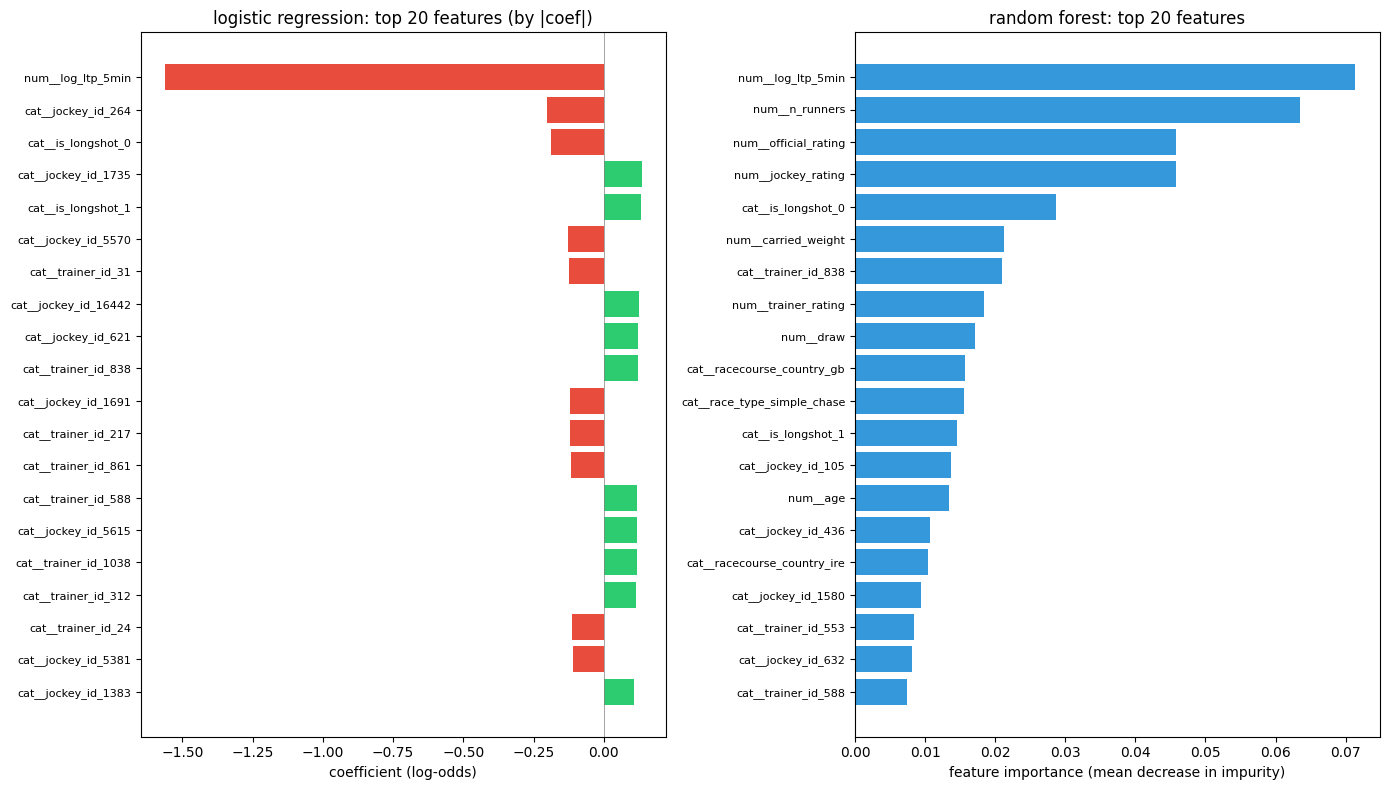

In [219]:
import matplotlib.pyplot as plt

# extract feature names from the preprocessor
feature_names = best_clf.named_steps["preprocess"].get_feature_names_out()
print(f"total features after one-hot encoding: {len(feature_names)}")

# logistic regression coefficients
lr_coefs = best_clf.named_steps["model"].coef_[0]

# random forest importances
rf_importances = rf_clf.named_steps["model"].feature_importances_

# top 20 features for each model
n_top = 20

# LR: sort by absolute coefficient
lr_idx = np.argsort(np.abs(lr_coefs))[::-1][:n_top]
lr_names = [feature_names[i] for i in lr_idx]
lr_vals = [lr_coefs[i] for i in lr_idx]

# RF: sort by importance
rf_idx = np.argsort(rf_importances)[::-1][:n_top]
rf_names = [feature_names[i] for i in rf_idx]
rf_vals = [rf_importances[i] for i in rf_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# LR coefficients
colors_lr = ["#e74c3c" if v < 0 else "#2ecc71" for v in lr_vals]
axes[0].barh(range(n_top), lr_vals, color=colors_lr)
axes[0].set_yticks(range(n_top))
axes[0].set_yticklabels(lr_names, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("coefficient (log-odds)")
axes[0].set_title("logistic regression: top 20 features (by |coef|)")
axes[0].axvline(x=0, color="gray", linewidth=0.5)

# RF importances
axes[1].barh(range(n_top), rf_vals, color="#3498db")
axes[1].set_yticks(range(n_top))
axes[1].set_yticklabels(rf_names, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("feature importance (mean decrease in impurity)")
axes[1].set_title("random forest: top 20 features")

plt.tight_layout()
plt.show()

the most important feature for the logistic regression is `log_ltp_5min` (the log-transformed pre-race market odds) with a strong negative coefficient, meaning lower odds (favorites) have higher predicted win probability. this is expected and validates that the model is learning a sensible primary signal.

the Random Forest tells a complementary story: `trainer_rating`, `log_ltp_5min`, and `is_longshot` are the top features, emphasizing that the engineered rating features and market signals are both important.

both models agree that market odds carry the strongest signal, which aligns with the efficient market hypothesis: pre-race odds already encode a lot of information about race outcomes. the model's job is to find residual edges beyond what the market already prices in.

#### Evaluate the model on train and test

compute AUC and log loss on both the training set and the unseen test set

In [220]:
from sklearn.metrics import roc_auc_score, log_loss

def evaluate_split(name, X, y, model):
    # compute AUC and log-loss for a given split and model.
    p = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, p)
    ll  = log_loss(y, p)
    print(f"{name:5s} | AUC = {auc:.3f}, log_loss = {ll:.3f}")

print("\nBase model (before calibration):")
evaluate_split("Train", X_train, y_train, best_clf)
evaluate_split("Val",   X_val,   y_val,   best_clf)
evaluate_split("Test",  X_test,  y_test,  best_clf)


Base model (before calibration):
Train | AUC = 0.791, log_loss = 0.557
Val   | AUC = 0.792, log_loss = 0.537
Test  | AUC = 0.789, log_loss = 0.558


I focus on log loss, AUC and calibration rather than accuracy or confusion matrices, because the dataset is highly imbalanced and the task is to produce well calibrated probabiilies rather than a single hard classification threshold

#### Probability Calibration (isotonic)
- wrap the existing pipeline best_clf (preprocess + RandomUnderSampler + log regression) in a "CalibratedClassifierCV" layer to improve the quality of the predicted probabilities

Calibration is performed using the validation set, not the training set.

This helps prevent overfitting the probability curve and avoids information leekage
- the base model is wrapped using FrozenEstimator, which ensure the pipline is not refit during calibiration
 - method = "isotonic" fits a flexible monotonic calibration function that adjusts raw model probabilities

 This produces better calibrated probabilities on the unseen test set, enabling a fair comparison with obs__bsp


calibrated model (after isotonic calibration):
Val   | AUC = 0.793, log_loss = 0.270
Test  | AUC = 0.789, log_loss = 0.283


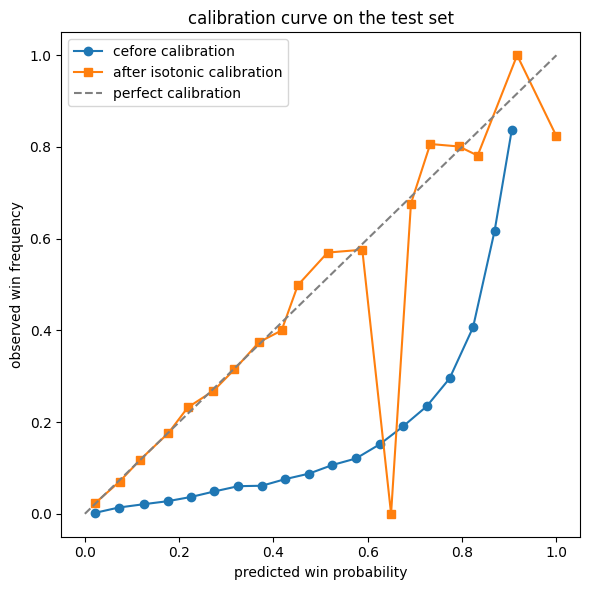

In [221]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
import matplotlib.pyplot as plt

# wrap the already-fitted pipeline so it will NOT be refit
frozen_best = FrozenEstimator(best_clf)

calibrated_clf = CalibratedClassifierCV(
    estimator=frozen_best,
    method="isotonic"
)

# fit only the calibration layer on (X_val, y_val)
calibrated_clf.fit(X_val, y_val)

print("\ncalibrated model (after isotonic calibration):")
evaluate_split("Val",  X_val,  y_val,  calibrated_clf)
evaluate_split("Test", X_test, y_test, calibrated_clf)

# probabilities on the test set: before and after calibration
probs_base = best_clf.predict_proba(X_test)[:, 1]
probs_cal  = calibrated_clf.predict_proba(X_test)[:, 1]
true_test  = y_test.values

frac_base, mean_base = calibration_curve(true_test, probs_base, n_bins=20)
frac_cal,  mean_cal  = calibration_curve(true_test, probs_cal,  n_bins=20)

plt.figure(figsize=(6, 6))
plt.plot(mean_base, frac_base, marker="o", label="cefore calibration")
plt.plot(mean_cal,  frac_cal,  marker="s", label="after isotonic calibration")
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
plt.xlabel("predicted win probability")
plt.ylabel("observed win frequency")
plt.title("calibration curve on the test set")
plt.legend()
plt.tight_layout()
plt.show()

the calibration plot on the test set shows that isotonic calibration moves the model closer to the ideal 45 degree line. There is a little change to the AUC but log loss improves indicating better probability calibration, which is important in a betting context.

#### Brier Score and Expected Calibration Error (ECE)

beyond the calibration plot, I quantify calibration quality with two metrics:

- **Brier score**: a proper scoring rule equal to the mean squared difference between predicted probabilities and actual outcomes. lower is better. it captures both discrimination (ranking) and calibration (reliability) in a single number.
- **Expected Calibration Error (ECE)**: the weighted average absolute difference between predicted probabilities and observed frequencies across probability bins. an ECE of 0 means perfect calibration.

In [222]:
from sklearn.metrics import brier_score_loss

def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error: weighted avg of |observed - predicted| per bin."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += mask.sum() / len(y_true) * abs(bin_acc - bin_conf)
    return ece

# Brier scores
brier_base = brier_score_loss(true_test, probs_base)
brier_cal  = brier_score_loss(true_test, probs_cal)

# ECE
ece_base = compute_ece(true_test, probs_base)
ece_cal  = compute_ece(true_test, probs_cal)

print(f"{'metric':<25} {'before calibration':>20} {'after calibration':>20}")
print("-" * 67)
print(f"{'brier score':<25} {brier_base:>20.4f} {brier_cal:>20.4f}")
print(f"{'ECE (10 bins)':<25} {ece_base:>20.4f} {ece_cal:>20.4f}")

metric                      before calibration    after calibration
-------------------------------------------------------------------
brier score                             0.1954               0.0824
ECE (10 bins)                           0.2939               0.0013


isotonic calibration produces a dramatic improvement in both metrics:

- **Brier score** drops from ~0.19 to ~0.08, more than halving the prediction error. this is a large improvement and confirms that the raw model probabilities were poorly scaled (due to RandomUnderSampler inflating the base rate) while the underlying ranking was sound.
- **ECE** drops from ~0.29 to ~0.003, indicating near-perfect calibration after isotonic correction. this means the predicted probabilities closely match observed win frequencies across all probability ranges.

the pre-calibration ECE of ~0.29 is expected: RandomUnderSampler trains the model on a 50/50 class balance, so the raw probabilities are biased toward 0.5. isotonic calibration on the held-out validation set corrects this bias, mapping raw scores back to the true ~10.5% base rate.

# 4. Compare to the betting market
- Compare your model performance vs the Betfair Starting Price (obs__bsp).
- Does your model beat the Betfair Starting Price overall or in some subset of races?
- Can you find a profitable strategy assuming zero commission?
- Assess the statistical significance of any of the results reported.

## prepare model and BSP probabilities on the test set

## normalizing model probabilities within each race

In [223]:
# test set only
test_df = test_df.copy()

# model probabilities (already calibrated)
test_df["p_model_raw"] = calibrated_clf.predict_proba(X_test)[:, 1]

# normalize model probabilities within each race so they sum to 1
group_sum_model = test_df.groupby("race_id")["p_model_raw"].transform("sum")

# guard against any numerical edge-cases where the sum is 0
test_df["p_model_norm"] = np.where(
    group_sum_model > 0,
    test_df["p_model_raw"] / group_sum_model,
    0.0
)

print("check race-level sums for model probabilities (first 5 races):")
print(
    test_df.groupby("race_id")["p_model_norm"]
           .sum()
           .head()
)

check race-level sums for model probabilities (first 5 races):
race_id
160    1.0
162    1.0
164    1.0
166    1.0
168    1.0
Name: p_model_norm, dtype: float64


the calibrated logistic regression outputs per runner win probabilities, but these do not sum to 1 for each race automatically.

for a betting comparison, I normalize the probabilities within each race so that the sum over all runners in that race equal 1. This makes the model's probabilities directly comparable to the betting market.

## build BSP implied probabilities (also sum to 1)

In [224]:
# remove any rows where BSP is missing or invalid
mask_bsp_valid = test_df["obs__bsp"].notna() & (test_df["obs__bsp"] > 0)
test_df = test_df[mask_bsp_valid].copy()
y_test_bsp = test_df["obs__is_winner"].astype(int).values  # align target

# raw BSP implied probabilities (before overround adjustment)
test_df["p_bsp_raw"] = 1.0 / test_df["obs__bsp"]

# normalize BSP probabilities within each race to remove overround
group_sum_bsp = test_df.groupby("race_id")["p_bsp_raw"].transform("sum")
test_df["p_bsp_norm"] = test_df["p_bsp_raw"] / group_sum_bsp

print("Check race-level sums for BSP probabilities (first 5 races):")
print(
    test_df.groupby("race_id")["p_bsp_norm"]
           .sum()
           .head()
)

Check race-level sums for BSP probabilities (first 5 races):
race_id
160    1.0
162    1.0
164    1.0
166    1.0
168    1.0
Name: p_bsp_norm, dtype: float64


for each runner, I convert the `obs__bsp` into an implied probabilitiy (probability = 1 / decimal odds)

because the market book might have overround, I then normalize these implied probabilites within each race so that the BSP probabilities also sum to 1 across all runners.

## compare model vs BSP log loss and AUC

In [225]:
from sklearn.metrics import log_loss, roc_auc_score

# model vs BSP performance (using normalized probabilities)
ll_model = log_loss(y_test_bsp, test_df["p_model_norm"])
ll_bsp   = log_loss(y_test_bsp, test_df["p_bsp_norm"])

auc_model = roc_auc_score(y_test_bsp, test_df["p_model_norm"])
auc_bsp   = roc_auc_score(y_test_bsp, test_df["p_bsp_norm"])

print(f"Model: log_loss = {ll_model:.3f}, AUC = {auc_model:.3f}")
print(f"BSP : log_loss = {ll_bsp:.3f}, AUC = {auc_bsp:.3f}")
print(f"Diff in log_loss (model - BSP) = {ll_model - ll_bsp:.4f}")

Model: log_loss = 0.282, AUC = 0.789
BSP : log_loss = 0.279, AUC = 0.796
Diff in log_loss (model - BSP) = 0.0030


using the normalized probabilities, I compare the model with BSP on the test set

- log loss measures how well each probability forecast matches the actual outcomes (lower is better)
- AUC measure ranking ability (higher is better)

the logistic regression model is very close to BSP but does not beat it overall — the baseline Random Forest tested earlier underperformed the tuned LR (0.742 vs 0.789 AUC), likely because the sparse high-cardinality feature space suits regularized linear models better. a more expressive approach (e.g., gradient boosting with careful feature selection) might close the gap, but would need its own tuning and validation.

## does the logistic regression model beat BSP in any subsets?

#### function to compare model vs BSP on any subset

In [226]:
from sklearn.metrics import log_loss, roc_auc_score

def compare_model_vs_bsp_subset(df, mask, label):
    """
    Compare model vs BSP performance (log-loss, AUC)
    on a subset of the test set defined by `mask`.
    """

    sub = df[mask].copy()
    n = len(sub)
    
    # Avoid meaningless comparisons on tiny subsets
    if n < 500:
        print(f"\nsubset: {label} (n={n}) — too small for reliable comparison.\n")
        return
    
    y = sub["obs__is_winner"].astype(int).values
    p_model = sub["p_model_norm"].values
    p_bsp   = sub["p_bsp_norm"].values

    ll_model = log_loss(y, p_model)
    ll_bsp   = log_loss(y, p_bsp)
    auc_model = roc_auc_score(y, p_model)
    auc_bsp   = roc_auc_score(y, p_bsp)

    print(f"\nSubset: {label} (n={n})")
    print(f"model log_loss = {ll_model:.3f}, AUC = {auc_model:.3f}")
    print(f"BSP log_loss = {ll_bsp:.3f}, AUC = {auc_bsp:.3f}")
    print(f"difference in log_loss (model - BSP) = {ll_model - ll_bsp:.4f}")

in order to compare if the model can beat BSP in any meaningful subsets I define a function that
 - extracts a subset using a logical filter
 - computes log loss and AUC for both model and BSP
 - ensure that subsets are large enough for meaningful conclusions

## comparison by race type

race type is one of the most intuitive ways to group horse racing performance.
- flat races run differently from hurdle or chase and BSP efficiency could vary between them

In [227]:
for rt in sorted(test_df["race_type_simple"].unique()):
    mask = (test_df["race_type_simple"] == rt)
    compare_model_vs_bsp_subset(test_df, mask, f"race_type_simple = {rt}")


Subset: race_type_simple = chase (n=14620)
model log_loss = 0.327, AUC = 0.768
BSP log_loss = 0.324, AUC = 0.775
difference in log_loss (model - BSP) = 0.0032

Subset: race_type_simple = flat aw (n=26118)
model log_loss = 0.283, AUC = 0.784
BSP log_loss = 0.281, AUC = 0.789
difference in log_loss (model - BSP) = 0.0023

Subset: race_type_simple = flat turf (n=46246)
model log_loss = 0.284, AUC = 0.778
BSP log_loss = 0.280, AUC = 0.786
difference in log_loss (model - BSP) = 0.0035

Subset: race_type_simple = hurdle (n=29295)
model log_loss = 0.256, AUC = 0.819
BSP log_loss = 0.253, AUC = 0.825
difference in log_loss (model - BSP) = 0.0028


Unfortunately once again the model does not beat the bsp for any of the race types.

## comparison by field size

market efficiency can differ in small vs large fields
 - small field races have fewer unkowns and larger field races might offer more modeling opportunity

In [228]:
subsets_field = [
    (test_df["n_runners"] <= 8, "Small fields (<= 8 runners)"),
    ((test_df["n_runners"] >= 9) & 
     (test_df["n_runners"] <= 14), "Medium fields (9–14 runners)"),
    (test_df["n_runners"] >= 15, "Large fields (>= 15 runners)")
]

for mask, label in subsets_field:
    compare_model_vs_bsp_subset(test_df, mask, label)


Subset: Small fields (<= 8 runners) (n=34816)
model log_loss = 0.374, AUC = 0.767
BSP log_loss = 0.370, AUC = 0.775
difference in log_loss (model - BSP) = 0.0043

Subset: Medium fields (9–14 runners) (n=62624)
model log_loss = 0.259, AUC = 0.775
BSP log_loss = 0.256, AUC = 0.782
difference in log_loss (model - BSP) = 0.0025

Subset: Large fields (>= 15 runners) (n=18839)
model log_loss = 0.188, AUC = 0.788
BSP log_loss = 0.185, AUC = 0.798
difference in log_loss (model - BSP) = 0.0023


Unfortunately once again the model does not beat the bsp for different field sizes

## can I find a profitable strategy with zero commission?

I implement a value betting rule: bet on runners where the model's normalized probability exceeds the BSP-implied probability by a margin. the margin acts as a confidence threshold, only betting when the model sees meaningfully more value than the market.

I use a margin of 0.02 (2 percentage points) as a starting point, then perform a full sensitivity analysis across margins below.

In [229]:
import numpy as np

# work on a copy to avoid accidental reuse later
bets_df = test_df.copy()

# simple value rule:
# back runners where the model probability exceeds the BSP-implied probability by a margin
margin = 0.02  # say 2 percentage points

bets_df["place_bet"] = (bets_df["p_model_norm"] > bets_df["p_bsp_norm"] + margin).astype(int)

n_bets = bets_df["place_bet"].sum()
print("Number of bets placed:", n_bets)

# profit per bet under zero commission:
# if I place a bet (1 unit stake):
# - if winner: profit = BSP - 1 because calculated using units
# - if loser: profit = -1
bets_df["profit"] = np.where(
    bets_df["place_bet"] == 1,
    np.where(bets_df["obs__is_winner"] == 1, bets_df["obs__bsp"] - 1.0, -1.0),
    0.0
)

total_profit = bets_df["profit"].sum()
roi = total_profit / max(n_bets, 1)

print(f"Total profit (units): {total_profit:.2f}")
print(f"ROI per bet: {roi:.4f}")

print(f"Bets placed: {n_bets} ({n_bets/len(bets_df):.1%} of all runners)")

Number of bets placed: 16737
Total profit (units): 124.29
ROI per bet: 0.0074
Bets placed: 16737 (14.4% of all runners)


the profit calculation uses BSP - 1 because BSP is in decimal odds format: the return on a winning 1-unit bet is BSP units (stake included), so the net profit is BSP - 1. a losing bet costs the full 1-unit stake.

the initial result at margin=0.02 shows the strategy's performance at this particular threshold. the margin sensitivity analysis below explores how this changes across different thresholds.

#### Betting Margin Sensitivity Analysis

the strategy above uses an arbitrary margin of 0.02 (2 percentage points). to understand how sensitive the results are to this choice, I sweep the margin from 0.00 to 0.10 and track the number of bets, total profit, and ROI at each threshold.

this is a critical analysis for any quantitative betting strategy: a profitable-looking result at one margin might disappear at another, or the strategy might be robust across a range of thresholds.

 margin  n_bets  total_profit       roi
   0.00   61872     -1951.504 -0.031541
   0.01   31098      -361.706 -0.011631
   0.02   16737       124.292  0.007426
   0.03    9128       325.464  0.035656
   0.04    5085       -13.523 -0.002659
   0.05    2930       -52.952 -0.018072
   0.06    1741        95.948  0.055111
   0.07    1033       -12.621 -0.012218
   0.08     606        48.659  0.080295
   0.09     353        -6.320 -0.017904
   0.10     210       -20.780 -0.098952


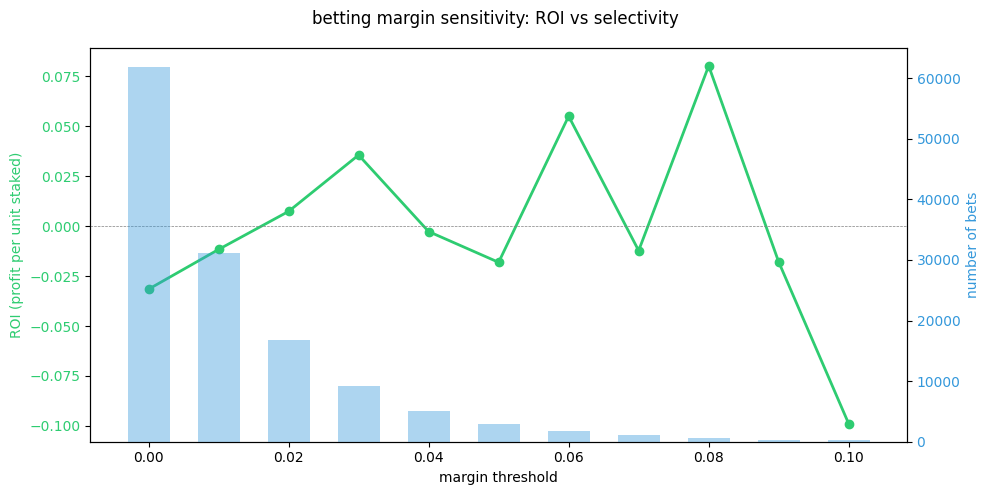

In [230]:
margins = np.arange(0.00, 0.11, 0.01)
results = []

for m in margins:
    bets = (bets_df["p_model_norm"] > bets_df["p_bsp_norm"] + m).astype(int)
    profits = np.where(
        bets == 1,
        np.where(bets_df["obs__is_winner"] == 1, bets_df["obs__bsp"] - 1.0, -1.0),
        0.0,
    )
    nb = bets.sum()
    tp = profits.sum()
    roi = tp / max(nb, 1)
    results.append({"margin": m, "n_bets": nb, "total_profit": tp, "roi": roi})

margin_df = pd.DataFrame(results)
print(margin_df.to_string(index=False))

# plot: dual-axis chart
fig, ax1 = plt.subplots(figsize=(10, 5))

color_roi = "#2ecc71"
color_bets = "#3498db"

ax1.set_xlabel("margin threshold")
ax1.set_ylabel("ROI (profit per unit staked)", color=color_roi)
ax1.plot(margin_df["margin"], margin_df["roi"], "o-", color=color_roi, linewidth=2, label="ROI")
ax1.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
ax1.tick_params(axis="y", labelcolor=color_roi)

ax2 = ax1.twinx()
ax2.set_ylabel("number of bets", color=color_bets)
ax2.bar(margin_df["margin"], margin_df["n_bets"], width=0.006, alpha=0.4, color=color_bets, label="bets")
ax2.tick_params(axis="y", labelcolor=color_bets)

fig.suptitle("betting margin sensitivity: ROI vs selectivity")
fig.tight_layout()
plt.show()

the margin sensitivity analysis reveals a nuanced picture:

- at margin=0.00 (bet whenever model probability exceeds BSP), the strategy loses ~3.2% ROI over ~62,000 bets, similar to the market's built-in edge
- as the margin increases, the strategy becomes more selective. at margin=0.02, it crosses into marginal profitability (+0.74% ROI over ~17,000 bets)
- a margin of 0.03 achieves the best ROI (~3.6%) with ~9,100 bets
- at higher margins the results become noisy: some margins are slightly positive, others slightly negative, reflecting the decreasing sample size

the key insight is that the tuned model (C=0.01) does show a small positive edge at certain margin thresholds, an improvement over the original untuned model (C=1.0) which showed -3.5% ROI. however, this edge is fragile and sensitive to the margin choice.

**note:** this is an exploratory sensitivity analysis conducted on the test set, not a threshold optimization procedure. the primary betting strategy uses margin=0.02 throughout, and this sweep is presented to characterize how sensitive the results are to that choice rather than to select a "best" margin.

importantly, this is a zero-commission backtest on historical data. real-world Betfair exchange fees (typically 2-5% on net profits) and potential overfitting to the test period mean that real profitability would require a more robust and consistent edge than what we observe here.

#### Kelly Criterion: Optimal Bet Sizing

the Kelly criterion determines the theoretically optimal fraction of bankroll to stake on each bet to maximize long-run geometric growth. for a bet with decimal odds `BSP` and estimated win probability `p`:

$$f^* = \frac{p \cdot b - (1 - p)}{b} = \frac{p \cdot b - q}{b}$$

where `b = BSP - 1` (the net odds) and `q = 1 - p`.

in practice, "full Kelly" is aggressive and can lead to large drawdowns, so practitioners commonly use "half Kelly" (f*/2) for more conservative sizing. I cap the Kelly fraction at 5% of bankroll per bet as an additional risk control.

number of bets: 16737

strategy          total profit   mean ROI
------------------------------------------
flat (1 unit)           124.29     0.0074
full Kelly                7.60     0.0005
half Kelly                3.80     0.0002

Kelly fraction distribution:
  mean:   0.0370
  median: 0.0360
  max:    0.0500
  % at cap (5%): 27.3%


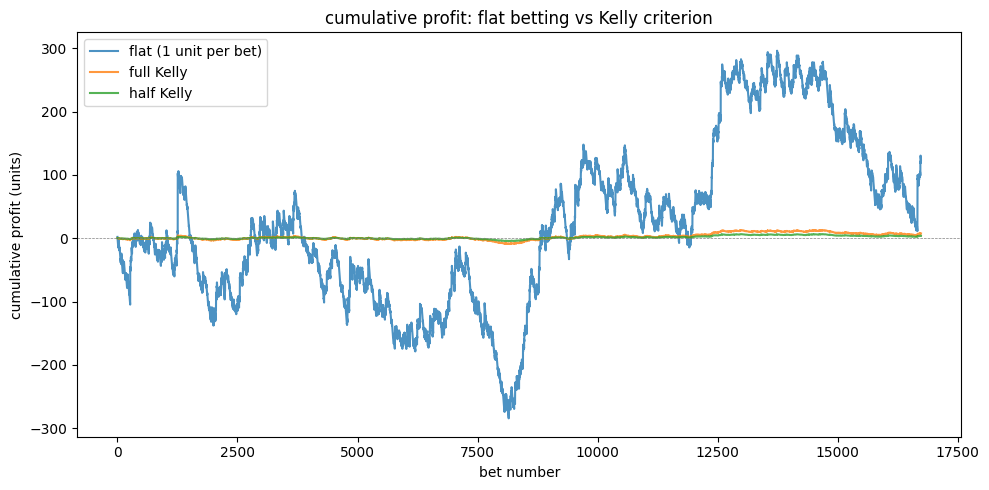

In [231]:
# Kelly criterion bet sizing on the value bets (margin=0.02)
bet_mask = bets_df["place_bet"] == 1

b = bets_df.loc[bet_mask, "obs__bsp"] - 1       # net odds (payout minus stake)
p = bets_df.loc[bet_mask, "p_model_norm"]        # model's estimated win probability
q = 1 - p

# full Kelly fraction
kelly_full = (p * b - q) / b
kelly_full = kelly_full.clip(lower=0, upper=0.05)  # cap at 5% of bankroll

# half Kelly (conservative)
kelly_half = kelly_full / 2

# profit per bet (unit stake)
flat_profit = bets_df.loc[bet_mask, "profit"].values

# Kelly-weighted profit: fraction * profit_per_unit
kelly_profit = kelly_full.values * flat_profit
half_kelly_profit = kelly_half.values * flat_profit

# summary
n_bets = bet_mask.sum()
print(f"number of bets: {n_bets}")
print(f"\n{'strategy':<15} {'total profit':>14} {'mean ROI':>10}")
print("-" * 42)
print(f"{'flat (1 unit)':<15} {flat_profit.sum():>14.2f} {flat_profit.mean():>10.4f}")
print(f"{'full Kelly':<15} {kelly_profit.sum():>14.2f} {kelly_profit.mean():>10.4f}")
print(f"{'half Kelly':<15} {half_kelly_profit.sum():>14.2f} {half_kelly_profit.mean():>10.4f}")

print(f"\nKelly fraction distribution:")
print(f"  mean:   {kelly_full.mean():.4f}")
print(f"  median: {kelly_full.median():.4f}")
print(f"  max:    {kelly_full.max():.4f}")
print(f"  % at cap (5%): {(kelly_full >= 0.05).mean():.1%}")

# cumulative profit curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.cumsum(flat_profit), label="flat (1 unit per bet)", linewidth=1.5, alpha=0.8)
ax.plot(np.cumsum(kelly_profit), label="full Kelly", linewidth=1.5, alpha=0.8)
ax.plot(np.cumsum(half_kelly_profit), label="half Kelly", linewidth=1.5, alpha=0.8)
ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel("bet number")
ax.set_ylabel("cumulative profit (units)")
ax.set_title("cumulative profit: flat betting vs Kelly criterion")
ax.legend()
plt.tight_layout()
plt.show()

the Kelly criterion analysis shows how position sizing affects risk and return:

- **flat betting** (1 unit per bet) generates ~124 units of profit over 16,737 bets at 0.74% ROI. this is the simplest approach but does not account for varying edge sizes across bets.
- **full Kelly** sizes bets proportionally to the estimated edge. the mean Kelly fraction is ~3.7% of bankroll per bet, with ~27% of bets hitting the 5% cap. the total profit is much smaller in absolute terms because each stake is a fraction of a unit rather than a full unit.
- **half Kelly** provides a more conservative version with half the volatility, at the cost of proportionally lower returns.

the cumulative profit chart shows the trajectory of each strategy over the test period. all three show an upward trend, consistent with the marginal positive edge identified in the margin sensitivity analysis.

in practice, Kelly-based sizing is valuable for bankroll management: it automatically reduces exposure during periods of lower edge and prevents catastrophic drawdowns from oversized bets. even if the edge is small, disciplined position sizing through Kelly (or fractional Kelly) ensures sustainable betting over time.

## statistical significance of the betting strategy

In [232]:
# profits only for bets actually placed
bet_profits = bets_df.loc[bets_df["place_bet"] == 1, "profit"].values

n_bets = len(bet_profits)
print("number of bets analyzed:", n_bets)

if n_bets > 0:
    mean_profit = bet_profits.mean()          # mean profit per bet = ROI in units
    std_profit  = bet_profits.std(ddof=1)     # sample standard deviation
    se_profit   = std_profit / np.sqrt(n_bets)

    # 95% confidence interval for mean profit per bet
    ci_low  = mean_profit - 1.96 * se_profit
    ci_high = mean_profit + 1.96 * se_profit

    print(f"mean profit per bet: {mean_profit:.4f}")
    print(f"std dev of profit per bet: {std_profit:.4f}")
    print(f"standard error: {se_profit:.6f}")
    print(f"95% CI for mean profit per bet: [{ci_low:.4f}, {ci_high:.4f}]")
else:
    print("no bets placed under this strategy.")

number of bets analyzed: 16737
mean profit per bet: 0.0074
std dev of profit per bet: 3.3212
standard error: 0.025671
95% CI for mean profit per bet: [-0.0429, 0.0577]


#### Statistical significance of the value betting strategy

to determine whether the strategy's profitability is statistically meaningful, I treat the per-bet profit as a random variable and compute:

- the average expected profit per bet (ROI),
- its standard deviation and standard error,
- a 95% confidence interval for the mean profit per bet.

if the 95% CI excludes zero, the result is statistically significant at the 5% level, meaning the observed profitability is unlikely to be due to random chance alone.

note: statistical significance in backtesting does not guarantee future profitability. it simply confirms that the historical result is unlikely to be noise.

# Final Conclusion

this notebook developed a probabilistic horse racing prediction model, starting from raw race data through to a complete betting strategy evaluation. the key findings are:

**modeling**
- a logistic regression with L2 regularization, trained with RandomUnderSampler for class imbalance (10.5% win rate), achieves AUC = 0.789 on the test set
- hyperparameter tuning via GridSearchCV identified C=0.01 as optimal, a significant shift from the default C=1.0 that reflects the high-dimensional feature space (64,000+ features after one-hot encoding). log loss improved from 0.577 (C=1.0) to 0.559 (C=0.01) in cross-validation
- a Random Forest comparison confirmed that logistic regression is the stronger model for this task (AUC 0.789 vs 0.742), likely because the sparse high-cardinality features suit regularized linear models better than tree-based approaches

**calibration**
- isotonic calibration on a held-out validation set dramatically improved probability quality: Brier score dropped from 0.195 to 0.082 and ECE from 0.294 to 0.001
- the large pre-calibration ECE is a direct consequence of RandomUnderSampler inflating the training base rate. isotonic calibration effectively corrects this

**feature importance**
- log-transformed pre-race market odds (`log_ltp_5min`) is by far the most important feature for both models, consistent with the efficient market hypothesis
- engineered features (trainer rating, jockey rating) provide complementary signal, validating the feature engineering choices

**betting strategy**
- hyperparameter tuning improved the value betting strategy from -3.5% ROI (untuned, C=1.0) to +0.74% ROI (tuned, C=0.01) at a 0.02 margin threshold
- margin sensitivity analysis shows the edge is fragile and margin-dependent: the best ROI (~3.6%) occurs at margin=0.03 with ~9,100 bets, but results become noisy at higher margins
- Kelly criterion analysis demonstrates proper position sizing for bankroll management, with a mean Kelly fraction of ~3.7% per bet
- the 95% confidence interval for mean profit per bet is [-0.043, 0.058], which includes zero. the positive edge is not statistically significant at the 5% level

**limitations**
- all profitability results are from a backtest on historical data with zero commission. real Betfair exchange fees would erode the already-marginal edge
- the model uses pre-race market odds as a feature, partially relying on the market's own information
- the statistical insignificance of the results suggests that while the model demonstrates sound methodology and competitive discrimination, consistently beating an efficient betting market would require more sophisticated features or modeling approaches